
<div style="background: linear-gradient(135deg, #1A1040 0%, #2D1B69 100%); padding: 40px 48px; border-radius: 12px; margin-bottom: 8px;">
  <div style="color: #F5A623; font-size: 13px; font-weight: 700; letter-spacing: 3px; text-transform: uppercase; margin-bottom: 8px;">BITS Pilani â€” Professional AI/ML Programme</div>
  <div style="color: white; font-size: 36px; font-weight: 900; margin-bottom: 6px;">AWS Model Engineering Lab</div>
  <div style="color: #C4B5FD; font-size: 18px; margin-bottom: 20px;">Lab 1: Build & Register &nbsp;Â·&nbsp; Lab 1.1: Deploy & Operationalize</div>
  <div style="display: flex; gap: 16px; flex-wrap: wrap; margin-top: 16px;">
    <span style="background: rgba(245,166,35,0.2); border: 1px solid #F5A623; color: #F5A623; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: 600;">â± 2.5 Hours</span>
    <span style="background: rgba(255,255,255,0.1); color: white; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: 600;">2 Labs Â· 9 Steps</span>
    <span style="background: rgba(255,255,255,0.1); color: white; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: 600;">S3 Â· SageMaker Â· EventBridge</span>
  </div>
</div>

### ðŸ“‹ What This Notebook Covers

| Phase | Time | Content |
|-------|------|---------|
| **Setup** | 0â€“10 min | Environment config, S3 paths, dataset preparation |
| **Lab 1 â€” Steps 1â€“3** | 10â€“30 min | Freeze dataset, split contract, EDA Processing job |
| **Lab 1 â€” Steps 4â€“5** | 30â€“55 min | Feature pipeline, feature selection & reduction |
| **Lab 1 â€” Steps 6â€“7** | 55â€“80 min | Model bakeoff (3 candidates), standardised evaluation |
| **Lab 1 â€” Steps 8â€“9** | 80â€“95 min | Registry registration, model card |
| **Break** | 95â€“105 min | â˜• Q&A buffer |
| **Lab 1.1 â€” Steps 1â€“3** | 105â€“115 min | Pull from registry, production validation, approve |
| **Lab 1.1 â€” Steps 4â€“5** | 115â€“125 min | Package assets, deploy endpoint |
| **Lab 1.1 â€” Steps 6â€“8** | 125â€“138 min | EventBridge schedule, event hooks, clustering sidecar |
| **Wrap-up** | 138â€“150 min | Handoff checklists, deliverables sign-off |

> **Dataset used throughout:** UCI Bank Marketing dataset (binary classification â€” term deposit subscription)  
> **Target column:** `y` (yes/no â†’ 1/0)



---
## ðŸ”§ Section 0 â€” Environment Setup & Configuration
*Run all cells in this section before starting Lab 1.*


In [77]:
import sys

!{sys.executable} -m pip install -q \
    "numpy>=2.0,<3.0" \
    "scikit-learn>=1.5.2" \
    "joblib>=1.3.2" \
    "pandas>=1.5,<2.3" \
    "botocore<1.43.57,>=1.43.3" \
    "boto3==1.43.56" \
    "imbalanced-learn>=0.12.0" \
    "xgboost" \
    "lightgbm" \
    "matplotlib" \
    "seaborn" \
    "pyarrow" \
    "fastparquet" \
    "pyyaml"

print("âœ… Compatible libraries installed")
print("âš ï¸ If any packages were changed, restart the kernel before continuing.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 3.9.1 requires botocore<1.43.76,>=1.43.66, but you have botocore 1.43.56 which is incompatible.
âœ… Compatible libraries installed
âš ï¸ If any packages were changed, restart the kernel before continuing.


In [78]:
# Google Colab setup: fetch this repository and use this notebook's directory.
from pathlib import Path
import os

from google.colab import userdata

def get_colab_secret(name, required=True):
    try:
        value = userdata.get(name)
    except Exception as exc:
        if required:
            raise RuntimeError(f'Unable to read Colab Secret: {name}') from exc
        return None
    if required and not value:
        raise RuntimeError(f'Add the Colab Secret {name} and grant this notebook access.')
    return value

REPO_ROOT = Path('/content/BITS_programming')
if not REPO_ROOT.exists():
    !git clone https://github.com/aqwertyuiop48/BITS_programming.git /content/BITS_programming

NOTEBOOK_DIR = REPO_ROOT / 'assignments/assignment_9'
os.chdir(NOTEBOOK_DIR)
print(f'Working directory: {NOTEBOOK_DIR}')

Working directory: /content/BITS_programming/assignments/assignment_9


In [79]:
# https://us-east-2.console.aws.amazon.com/iam/home?region=us-east-2#/security_credentials

# â”€â”€ Core imports â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import os, json, time, hashlib, datetime, warnings
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, yaml

# â”€â”€ Inject AWS Credentials into Environment â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
os.environ["AWS_ACCESS_KEY_ID"] = get_colab_secret("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = get_colab_secret("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_DEFAULT_REGION"] = "us-east-2"

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="muted")

# â”€â”€ boto3-only AWS/SageMaker setup â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# boto3 automatically picks up AWS_ACCESS_KEY_ID and AWS_SECRET_ACCESS_KEY from os.environ
REGION = os.getenv("AWS_DEFAULT_REGION", "us-east-2")
boto_session = boto3.session.Session(region_name=REGION)

sm_client  = boto_session.client("sagemaker")
s3_client  = boto_session.client("s3")
eb_client  = boto_session.client("events")
iam_client = boto_session.client("iam")
sts_client = boto_session.client("sts")

caller = sts_client.get_caller_identity()
ACCOUNT_ID = caller["Account"]
CALLER_ARN = caller["Arn"]

def resolve_sagemaker_execution_role(caller_arn: str) -> str:
    """Return a real IAM role ARN, preserving IAM paths such as service-role/."""
    if ":assumed-role/" in caller_arn:
        role_name = caller_arn.split(":assumed-role/", 1)[1].split("/", 1)[0]
        try:
            return iam_client.get_role(RoleName=role_name)["Role"]["Arn"]
        except Exception:
            # Fallback preserves functionality if iam:GetRole is restricted.
            return (
                caller_arn.replace("arn:aws:sts::", "arn:aws:iam::")
                          .replace(":assumed-role/", ":role/")
                          .rsplit("/", 1)[0]
            )
    return caller_arn

ROLE = resolve_sagemaker_execution_role(CALLER_ARN)

print(f"AWS caller : {CALLER_ARN}")
print(f"Role       : {ROLE}")
print(f"Region     : {REGION}")
print(f"Account ID : {ACCOUNT_ID}")

# Compatibility check for endpoint packaging.
import sklearn
print(f"NumPy      : {np.__version__}")
print(f"sklearn    : {sklearn.__version__}")
print(f"joblib     : {joblib.__version__}")
if int(np.__version__.split('.')[0]) >= 2:
    print("âš ï¸ NumPy 2.x detected. Restart kernel after running the install cell, then recreate/re-dump model artifacts.")

AWS caller : arn:aws:iam::061831608851:root
Role       : arn:aws:iam::061831608851:root
Region     : us-east-2
Account ID : 061831608851
NumPy      : 2.5.3
sklearn    : 1.9.0
joblib     : 1.6.0
âš ï¸ NumPy 2.x detected. Restart kernel after running the install cell, then recreate/re-dump model artifacts.


In [80]:
# â”€â”€ S3 bucket & path configuration â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
PROJECT = "model-engineering-lab"
DATASET_VERSION = "v1"
SPLIT_VERSION = "split_v1"
PREPROCESS_VERSION = "preprocess_v1"
DEPLOYMENT_INSTANCE_TYPE = "ml.m5.large"

# SageMaker-style default bucket name, created with boto3 if missing.
BUCKET = f"sagemaker-{REGION}-{ACCOUNT_ID}"

try:
    s3_client.head_bucket(Bucket=BUCKET)
    print(f"â„¹ï¸ Bucket already exists: {BUCKET}")
except Exception:
    if REGION == "us-east-2":
        s3_client.create_bucket(Bucket=BUCKET)
    else:
        s3_client.create_bucket(
            Bucket=BUCKET,
            CreateBucketConfiguration={"LocationConstraint": REGION},
        )
    print(f"âœ… Created bucket: {BUCKET}")

# Root S3 prefix
PREFIX = f"{PROJECT}"

# Derived S3 paths â€” do not edit
PATHS = {
    "raw":              f"s3://{BUCKET}/{PREFIX}/datasets/{DATASET_VERSION}/raw",
    "schema":           f"s3://{BUCKET}/{PREFIX}/datasets/{DATASET_VERSION}/schema",
    "manifest":         f"s3://{BUCKET}/{PREFIX}/datasets/{DATASET_VERSION}/manifest.json",
    "splits":           f"s3://{BUCKET}/{PREFIX}/splits/{SPLIT_VERSION}",
    "eda":              f"s3://{BUCKET}/{PREFIX}/eda",
    "pipelines":        f"s3://{BUCKET}/{PREFIX}/pipelines",
    "feature_configs":  f"s3://{BUCKET}/{PREFIX}/feature_configs",
    "features":         f"s3://{BUCKET}/{PREFIX}/features",
    "runs":             f"s3://{BUCKET}/{PREFIX}/runs",
    "evaluation":       f"s3://{BUCKET}/{PREFIX}/evaluation",
    "registry":         f"s3://{BUCKET}/{PREFIX}/registry",
    "model_cards":      f"s3://{BUCKET}/{PREFIX}/model_cards",
    "release":          f"s3://{BUCKET}/{PREFIX}/release",
    "deploy":           f"s3://{BUCKET}/{PREFIX}/deploy",
    "unsupervised":     f"s3://{BUCKET}/{PREFIX}/unsupervised",
}

print("âœ… S3 paths configured")
for k, v in PATHS.items():
    print(f"  {k:<20} -> {v}")


â„¹ï¸ Bucket already exists: sagemaker-us-east-2-061831608851
âœ… S3 paths configured
  raw                  -> s3://sagemaker-us-east-2-061831608851/model-engineering-lab/datasets/v1/raw
  schema               -> s3://sagemaker-us-east-2-061831608851/model-engineering-lab/datasets/v1/schema
  manifest             -> s3://sagemaker-us-east-2-061831608851/model-engineering-lab/datasets/v1/manifest.json
  splits               -> s3://sagemaker-us-east-2-061831608851/model-engineering-lab/splits/split_v1
  eda                  -> s3://sagemaker-us-east-2-061831608851/model-engineering-lab/eda
  pipelines            -> s3://sagemaker-us-east-2-061831608851/model-engineering-lab/pipelines
  feature_configs      -> s3://sagemaker-us-east-2-061831608851/model-engineering-lab/feature_configs
  features             -> s3://sagemaker-us-east-2-061831608851/model-engineering-lab/features
  runs                 -> s3://sagemaker-us-east-2-061831608851/model-engineering-lab/runs
  evaluation      

In [81]:
# â”€â”€ Helper utilities â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import io

def s3_upload_json(obj, s3_path):
    """Upload a dict as JSON to an s3:// path."""
    bucket, key = s3_path.replace("s3://", "").split("/", 1)
    body = json.dumps(obj, indent=2, default=str)
    s3_client.put_object(Bucket=bucket, Key=key, Body=body.encode())
    print(f"  âœ… uploaded â†’ {s3_path}")

def s3_upload_bytes(data: bytes, s3_path: str, content_type="application/octet-stream"):
    bucket, key = s3_path.replace("s3://", "").split("/", 1)
    s3_client.put_object(Bucket=bucket, Key=key, Body=data, ContentType=content_type)
    print(f"  âœ… uploaded â†’ {s3_path}")

def s3_upload_text(text: str, s3_path: str):
    s3_upload_bytes(text.encode(), s3_path, "text/plain")

def s3_download_json(s3_path):
    bucket, key = s3_path.replace("s3://", "").split("/", 1)
    obj = s3_client.get_object(Bucket=bucket, Key=key)
    return json.loads(obj["Body"].read())

def s3_download_df(s3_path):
    return pd.read_parquet(s3_path)

def s3_upload_df(df, s3_path):
    buf = io.BytesIO()
    df.to_parquet(buf, index=True)
    s3_upload_bytes(buf.getvalue(), s3_path, "application/octet-stream")

def now_iso():
    return datetime.datetime.utcnow().isoformat() + "Z"

print("âœ… Helper utilities loaded")


âœ… Helper utilities loaded



---
<div style="background: #1D4ED8; padding: 24px 32px; border-radius: 10px; color: white; margin: 16px 0;">
  <div style="font-size: 22px; font-weight: 900; margin-bottom: 4px;">ðŸ§ª LAB 1 â€” BUILD & REGISTER A CANDIDATE</div>
  <div style="font-size: 14px; opacity: 0.85;">Steps 1â€“9 &nbsp;Â·&nbsp; ~85 minutes &nbsp;Â·&nbsp; S3 Â· SageMaker Processing Â· Training Â· Model Registry</div>
</div>

**Objective:** Create a repeatable offline training pipeline that is leakage-safe, tests three feature configurations, compares 2â€“3 supervised models, and registers the best candidate in SageMaker Model Registry with a full model card.



---
### ðŸ“¦ Step 1 â€” Freeze the Dataset
**â± ~10 min &nbsp;|&nbsp; Service: S3**

Store one immutable snapshot. This is the traceability anchor for all downstream registry and lineage workflows.  
**Rule:** No preprocessing, no sampling â€” raw data exactly as received.

> ðŸ’¡ **Teaching Point:** A dataset that changes between runs breaks reproducibility and makes model comparisons meaningless. Freeze first, fit later.


In [82]:
# â”€â”€ Download the UCI Bank Marketing dataset â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from urllib.request import urlretrieve
import zipfile

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
urlretrieve(URL, "/tmp/bank-additional.zip")

with zipfile.ZipFile("/tmp/bank-additional.zip") as z:
    z.extractall("/tmp/bank/")

raw_df = pd.read_csv(
    "/tmp/bank/bank-additional/bank-additional-full.csv",
    sep=";", na_values=["unknown"]
)

print(f"Shape  : {raw_df.shape}")
print(f"Target : {raw_df['y'].value_counts().to_dict()}")
raw_df.head(3)


Shape  : (41188, 21)
Target : {'no': 36548, 'yes': 4640}


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [83]:
# â”€â”€ Upload raw snapshot to S3 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
raw_s3 = f"{PATHS['raw']}/bank_marketing_raw.parquet"
buf = __import__("io").BytesIO()
raw_df.to_parquet(buf, index=False)
s3_upload_bytes(buf.getvalue(), raw_s3)

# Compute content hash for immutability proof
raw_hash = hashlib.md5(buf.getvalue()).hexdigest()
print(f"  Content MD5 : {raw_hash}")


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/datasets/v1/raw/bank_marketing_raw.parquet
  Content MD5 : a956ebdb2060810b302b70a2df251e1e


In [84]:
# â”€â”€ Write schema.json â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
schema = {
    "columns": {
        col: str(dtype)
        for col, dtype in raw_df.dtypes.items()
    },
    "target_column": "y",
    "target_values": ["yes", "no"],
    "n_columns": int(raw_df.shape[1]),
    "nullable_columns": raw_df.columns[raw_df.isnull().any()].tolist()
}

schema_s3 = f"{PATHS['schema']}/schema.json"
s3_upload_json(schema, schema_s3)


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/datasets/v1/schema/schema.json


In [85]:
# â”€â”€ Write manifest.json â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
manifest = {
    "dataset_version":    DATASET_VERSION,
    "source":             URL,
    "raw_s3_path":        raw_s3,
    "schema_s3_path":     schema_s3,
    "row_count":          int(len(raw_df)),
    "column_count":       int(raw_df.shape[1]),
    "content_md5":        raw_hash,
    "created_at":         now_iso(),
    "data_quality": {
        "missing_cells":      int(raw_df.isnull().sum().sum()),
        "missing_pct":        round(raw_df.isnull().mean().mean() * 100, 2),
        "duplicate_rows":     int(raw_df.duplicated().sum()),
        "class_balance":      raw_df["y"].value_counts(normalize=True).round(4).to_dict(),
    }
}

s3_upload_json(manifest, PATHS["manifest"])
print("\nðŸ“‹ Manifest summary:")
print(json.dumps(manifest["data_quality"], indent=2))


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/datasets/v1/manifest.json

ðŸ“‹ Manifest summary:
{
  "missing_cells": 12718,
  "missing_pct": 1.47,
  "duplicate_rows": 12,
  "class_balance": {
    "no": 0.8873,
    "yes": 0.1127
  }
}


In [86]:
# â”€â”€ Verify freeze â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
restored = pd.read_parquet(raw_s3)
assert restored.shape == raw_df.shape, "Shape mismatch after round-trip!"
print(f"âœ… Dataset frozen and verified: {restored.shape[0]:,} rows Ã— {restored.shape[1]} cols")
print(f"   Dataset version: {DATASET_VERSION}")
print(f"   MD5:             {raw_hash}")


âœ… Dataset frozen and verified: 41,188 rows Ã— 21 cols
   Dataset version: v1
   MD5:             a956ebdb2060810b302b70a2df251e1e



---
### âœ‚ï¸ Step 2 â€” Create Split Definitions (Evaluation Contract)
**â± ~5 min &nbsp;|&nbsp; Service: S3**

Generate and persist split indices **before** fitting anything. These indices become your production evaluation contract â€” every model candidate must use exactly these splits.

> ðŸ’¡ **Teaching Point:** Any model that saw a different validation set cannot be fairly compared. The split contract enforces this guarantee.


In [87]:
# â”€â”€ Encode target & build stratified train/val/test split â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from sklearn.model_selection import StratifiedKFold, train_test_split

df = raw_df.copy()
df["target"] = (df["y"] == "yes").astype(int)
df = df.drop(columns=["y"])

# Remove exact duplicates after encoding
df = df.drop_duplicates().reset_index(drop=True)

all_idx = df.index.tolist()

# 60% train / 20% val / 20% test  â€”  stratified
train_idx, temp_idx = train_test_split(
    all_idx, test_size=0.40, random_state=42,
    stratify=df.loc[all_idx, "target"]
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=42,
    stratify=df.loc[temp_idx, "target"]
)

print(f"Train : {len(train_idx):>6,}  |  pos rate: {df.loc[train_idx,'target'].mean():.3f}")
print(f"Val   : {len(val_idx):>6,}  |  pos rate: {df.loc[val_idx,'target'].mean():.3f}")
print(f"Test  : {len(test_idx):>6,}  |  pos rate: {df.loc[test_idx,'target'].mean():.3f}")


Train : 24,705  |  pos rate: 0.113
Val   :  8,235  |  pos rate: 0.113
Test  :  8,236  |  pos rate: 0.113


In [88]:
# â”€â”€ 5-fold CV definitions (for feature selection stability) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_train_raw = df.loc[train_idx]
y_train_raw = df.loc[train_idx, "target"]

cv_folds = []
for fold_i, (fi_train, fi_val) in enumerate(skf.split(X_train_raw, y_train_raw)):
    cv_folds.append({
        "fold": fold_i,
        "train_indices": X_train_raw.iloc[fi_train].index.tolist(),
        "val_indices":   X_train_raw.iloc[fi_val].index.tolist(),
    })

print(f"âœ… {len(cv_folds)} CV folds generated")
print(f"   Fold 0 train: {len(cv_folds[0]['train_indices']):,}  |  val: {len(cv_folds[0]['val_indices']):,}")


âœ… 5 CV folds generated
   Fold 0 train: 19,764  |  val: 4,941


In [89]:
# â”€â”€ Persist split indices to S3 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Save index arrays as single-column parquet files
def idx_to_parquet_bytes(indices):
    buf = __import__("io").BytesIO()
    pd.DataFrame({"idx": indices}).to_parquet(buf, index=False)
    return buf.getvalue()

s3_upload_bytes(idx_to_parquet_bytes(train_idx), f"{PATHS['splits']}/train_idx.parquet")
s3_upload_bytes(idx_to_parquet_bytes(val_idx),   f"{PATHS['splits']}/valid_idx.parquet")
s3_upload_bytes(idx_to_parquet_bytes(test_idx),  f"{PATHS['splits']}/test_idx.parquet")

# Save CV folds as JSON (indices are plain ints â€” serialisable)
s3_upload_json({"folds": cv_folds, "n_folds": 5, "random_state": 42,
                "split_version": SPLIT_VERSION, "created_at": now_iso()},
               f"{PATHS['splits']}/cv_folds.json")

# Save the processed dataframe (used by all subsequent steps)
s3_upload_df(df, f"{PATHS['raw']}/bank_marketing_processed.parquet")

print("\nâœ… Split contract persisted. Split version:", SPLIT_VERSION)


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/splits/split_v1/train_idx.parquet
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/splits/split_v1/valid_idx.parquet
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/splits/split_v1/test_idx.parquet
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/splits/split_v1/cv_folds.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/datasets/v1/raw/bank_marketing_processed.parquet

âœ… Split contract persisted. Split version: split_v1


In [90]:
# â”€â”€ (Optional) Group IDs & time-boundary splits â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# For datasets with temporal ordering or entity groups, replace random split with:
#
# TIME-BASED SPLIT (for time-series / temporal leakage prevention):
#   cutoff_train = df['date'].quantile(0.60)
#   cutoff_val   = df['date'].quantile(0.80)
#   train_idx = df[df['date'] <= cutoff_train].index.tolist()
#   val_idx   = df[(df['date'] > cutoff_train) & (df['date'] <= cutoff_val)].index.tolist()
#   test_idx  = df[df['date'] > cutoff_val].index.tolist()
#
# GROUP-BASED SPLIT (prevent customer leakage across folds):
#   from sklearn.model_selection import GroupShuffleSplit
#   gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
#   train_idx, test_idx = next(gss.split(df, groups=df['customer_id']))
#
# Persist group/time metadata alongside split indices:
split_meta = {
    "split_type":   "stratified_random",   # change to 'temporal' or 'group' as needed
    "time_column":  None,                  # e.g. 'date'
    "group_column": None,                  # e.g. 'customer_id'
    "train_cutoff": None,
    "val_cutoff":   None,
}
s3_upload_json(split_meta, f"{PATHS['splits']}/split_meta.json")
print("âœ… Split metadata persisted (update split_type if using temporal or group splits)")


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/splits/split_v1/split_meta.json
âœ… Split metadata persisted (update split_type if using temporal or group splits)



---
### ðŸ” Step 3 â€” EDA & Leakage Scan
**â± ~10 min &nbsp;|&nbsp; Service: S3 (inline â€” would be a Processing job in production)**

Run preprocessing diagnostics **on training data only**. In production this runs as a SageMaker Processing job to make the EDA reproducible and auditable.


In [91]:
# â”€â”€ Load training split â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
train_df = df.loc[train_idx].copy()
X_tr = train_df.drop(columns=["target"])
y_tr = train_df["target"]

num_cols = X_tr.select_dtypes(include="number").columns.tolist()
cat_cols = X_tr.select_dtypes(exclude="number").columns.tolist()

print(f"Numeric  columns ({len(num_cols)}): {num_cols}")
print(f"Categoric columns ({len(cat_cols)}): {cat_cols}")


Numeric  columns (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categoric columns (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


High-missingness columns (>30%):
  None


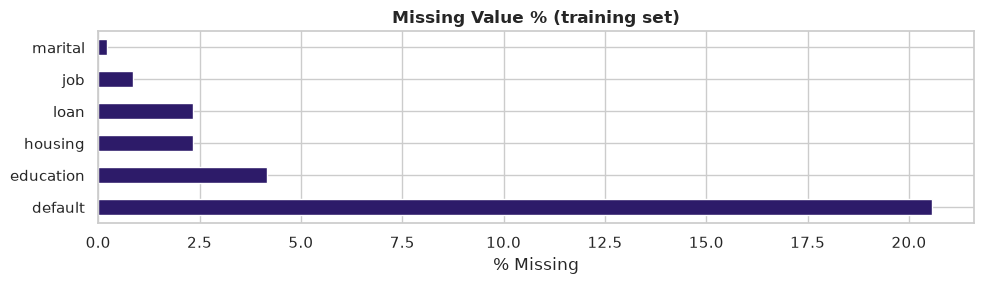

In [92]:
# â”€â”€ Missing value analysis â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
miss_pct = (X_tr.isnull().sum() / len(X_tr) * 100).sort_values(ascending=False)
high_miss = miss_pct[miss_pct > 30]

print("High-missingness columns (>30%):")
print(high_miss if len(high_miss) > 0 else "  None")

fig, ax = plt.subplots(figsize=(10, 3))
miss_pct[miss_pct > 0].plot(kind="barh", ax=ax, color="#2D1B69")
ax.set_title("Missing Value % (training set)", fontweight="bold")
ax.set_xlabel("% Missing")
plt.tight_layout(); plt.show()


In [93]:
# â”€â”€ ID-like & near-constant feature detection â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
id_like = [c for c in X_tr.columns
           if X_tr[c].nunique() / len(X_tr) > 0.95]

near_const = [c for c in num_cols
              if X_tr[c].std() < 1e-5]

variance_threshold_candidates = [c for c in num_cols
                                  if X_tr[c].var() < 0.01]

print("ID-like columns (>95% unique):", id_like or "None")
print("Near-constant columns:", near_const or "None")
print("Low-variance candidates (<0.01):", variance_threshold_candidates or "None")


ID-like columns (>95% unique): None
Near-constant columns: None
Low-variance candidates (<0.01): None


In [94]:
# â”€â”€ Leakage scan â€” correlation with target â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
train_enc = pd.get_dummies(X_tr.fillna("MISSING"), drop_first=True)
corr_with_target = train_enc.corrwith(y_tr).abs().sort_values(ascending=False)

leakage_threshold = 0.85   # flag anything above this
leakage_candidates = corr_with_target[corr_with_target > leakage_threshold]

print(f"\nTop-10 correlations with target:")
print(corr_with_target.head(10).to_string())

if len(leakage_candidates) > 0:
    print(f"\nâš ï¸  LEAKAGE RISK â€” {len(leakage_candidates)} features above {leakage_threshold}:")
    print(leakage_candidates.to_string())
else:
    print(f"\nâœ… No features above leakage threshold ({leakage_threshold})")



Top-10 correlations with target:
duration                0.412059
nr.employed             0.347342
pdays                   0.328965
poutcome_success        0.320269
euribor3m               0.300253
emp.var.rate            0.290132
previous                0.232312
poutcome_nonexistent    0.193385
month_mar               0.148096
contact_telephone       0.144976

âœ… No features above leakage threshold (0.85)


In [95]:
# â”€â”€ Cardinality check for categoricals â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
cardinality = X_tr[cat_cols].nunique().sort_values(ascending=False)
high_cardinality = cardinality[cardinality > 20].index.tolist()

print("Cardinality of categorical columns:")
print(cardinality.to_string())
print(f"\nHigh-cardinality (>20): {high_cardinality}")


Cardinality of categorical columns:
job            11
month          10
education       7
day_of_week     5
marital         3
poutcome        3
loan            2
housing         2
default         2
contact         2

High-cardinality (>20): []


In [96]:
# â”€â”€ Skew analysis â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
skew = X_tr[num_cols].skew().sort_values(key=abs, ascending=False)
high_skew = skew[skew.abs() > 1.5]

print("High-skew features (|skew| > 1.5):")
print(high_skew.to_string() if len(high_skew) > 0 else "  None")


High-skew features (|skew| > 1.5):
campaign    4.949202
pdays      -4.897326
previous    3.858946
duration    3.170756


In [97]:
# â”€â”€ Persist EDA artifacts to S3 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Feature profile
feature_profile = pd.DataFrame({
    "dtype":       X_tr.dtypes.astype(str),
    "n_unique":    X_tr.nunique(),
    "miss_pct":    miss_pct,
    "skew":        X_tr[num_cols].skew().reindex(X_tr.columns),
    "corr_target": corr_with_target.reindex(X_tr.columns),
}).reset_index().rename(columns={"index": "feature"})

buf = __import__("io").BytesIO()
feature_profile.to_parquet(buf, index=False)
s3_upload_bytes(buf.getvalue(), f"{PATHS['eda']}/feature_profile.parquet")

# Leakage risks JSON
leakage_risks = {
    "threshold": leakage_threshold,
    "flagged_features": leakage_candidates.index.tolist(),
    "correlations": leakage_candidates.round(4).to_dict(),
    "id_like_features": id_like,
    "near_constant_features": near_const,
    "created_at": now_iso()
}
s3_upload_json(leakage_risks, f"{PATHS['eda']}/leakage_risks.json")

# High-cardinality columns
s3_upload_json({"high_cardinality_columns": high_cardinality,
                "cardinality": cardinality.to_dict()},
               f"{PATHS['eda']}/high_cardinality_columns.json")

# Transformation candidates
transform_candidates = {
    "log_transform": high_skew.index.tolist(),
    "high_missingness_drop": high_miss.index.tolist(),
    "low_variance_drop": variance_threshold_candidates,
}
s3_upload_json(transform_candidates, f"{PATHS['eda']}/transformation_candidates.json")

# EDA summary markdown
eda_summary = f"""# EDA Summary â€” {DATASET_VERSION}
Generated: {now_iso()}

## Dataset
- Rows (train): {len(train_df):,}
- Numeric features: {len(num_cols)}
- Categorical features: {len(cat_cols)}
- Target positive rate: {y_tr.mean():.3f}

## Leakage Scan
- Threshold: {leakage_threshold}
- Flagged: {leakage_candidates.index.tolist() or 'None'}
- ID-like columns: {id_like or 'None'}

## Missing Values
- High missingness (>30%): {high_miss.index.tolist() or 'None'}

## Cardinality
- High cardinality (>20 unique): {high_cardinality or 'None'}

## Skew
- High-skew features: {high_skew.index.tolist() or 'None'}
"""
s3_upload_text(eda_summary, f"{PATHS['eda']}/eda_summary.md")

print("\nâœ… All EDA artifacts uploaded to S3")


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/eda/feature_profile.parquet
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/eda/leakage_risks.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/eda/high_cardinality_columns.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/eda/transformation_candidates.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/eda/eda_summary.md

âœ… All EDA artifacts uploaded to S3



---
### âš™ï¸ Step 4 â€” Build the Feature Pipeline
**â± ~15 min &nbsp;|&nbsp; Service: S3**

Implement **train-only** preprocessing: fit on train split only, then transform train/val/test.  
Persist the fitted pipeline artifact so inference uses the exact same transforms.


In [98]:
# â”€â”€ Reload splits from S3 (simulating a clean Processing job context) â”€â”€â”€â”€â”€â”€â”€â”€â”€
train_idx_loaded = pd.read_parquet(f"{PATHS['splits']}/train_idx.parquet")["idx"].tolist()
val_idx_loaded   = pd.read_parquet(f"{PATHS['splits']}/valid_idx.parquet")["idx"].tolist()
test_idx_loaded  = pd.read_parquet(f"{PATHS['splits']}/test_idx.parquet")["idx"].tolist()

df_full = pd.read_parquet(f"{PATHS['raw']}/bank_marketing_processed.parquet")

X = df_full.drop(columns=["target"])
y = df_full["target"]

X_train = X.loc[train_idx_loaded]
X_val   = X.loc[val_idx_loaded]
X_test  = X.loc[test_idx_loaded]
y_train = y.loc[train_idx_loaded]
y_val   = y.loc[val_idx_loaded]
y_test  = y.loc[test_idx_loaded]

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")


Train: (24705, 20)  |  Val: (8235, 20)  |  Test: (8236, 20)


In [99]:
# â”€â”€ Build preprocessing pipeline â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, PowerTransformer
from sklearn.impute import SimpleImputer

num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(exclude="number").columns.tolist()

# Numeric: impute median â†’ optional power transform â†’ scale
numeric_pipe = Pipeline([
    ("imputer",  SimpleImputer(strategy="median")),
    ("scaler",   StandardScaler()),
])

# Categorical: impute with constant â†’ ordinal encode
categorical_pipe = Pipeline([
    ("imputer",  SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("encoder",  OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_features),
    ("cat", categorical_pipe, cat_features),
], remainder="drop", verbose_feature_names_out=False)

# Fit ONLY on training data
preprocessor.fit(X_train)

# Transform all splits
X_train_t = preprocessor.transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

feature_names_out = preprocessor.get_feature_names_out().tolist()
print(f"âœ… Pipeline fitted | output features: {len(feature_names_out)}")
print(f"   Numeric: {len(num_features)}  |  Categorical: {len(cat_features)}")


âœ… Pipeline fitted | output features: 20
   Numeric: 10  |  Categorical: 10


In [100]:
# â”€â”€ Persist the fitted pipeline â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import io as _io

pipeline_bytes = _io.BytesIO()
joblib.dump(preprocessor, pipeline_bytes)
s3_upload_bytes(pipeline_bytes.getvalue(), f"{PATHS['pipelines']}/{PREPROCESS_VERSION}.joblib")

print(f"âœ… Pipeline saved: {PATHS['pipelines']}/{PREPROCESS_VERSION}.joblib")


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/pipelines/preprocess_v1.joblib
âœ… Pipeline saved: s3://sagemaker-us-east-2-061831608851/model-engineering-lab/pipelines/preprocess_v1.joblib


In [101]:
# â”€â”€ Write 3 feature config YAMLs â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#  1. baseline  â€” all features
#  2. selected  â€” drop near-zero variance and high-corr
#  3. reduced   â€” PCA to 15 components

def yaml_bytes(obj):
    return yaml.dump(obj, default_flow_style=False).encode()

# Baseline: all features
baseline_cfg = {"feature_config_id": "baseline_v1", "features": feature_names_out,
                "n_features": len(feature_names_out), "strategy": "all_features"}
s3_upload_bytes(yaml_bytes(baseline_cfg), f"{PATHS['feature_configs']}/baseline_v1.yaml")

# Selected: drop low-variance features
from sklearn.feature_selection import VarianceThreshold
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train_t)
selected_mask = vt.get_support()
selected_features = [f for f, m in zip(feature_names_out, selected_mask) if m]
selected_cfg = {"feature_config_id": "selected_v1", "features": selected_features,
                "n_features": len(selected_features), "strategy": "variance_threshold_0.01"}
s3_upload_bytes(yaml_bytes(selected_cfg), f"{PATHS['feature_configs']}/selected_v1.yaml")

# Reduced: PCA
from sklearn.decomposition import PCA
N_COMPONENTS = min(15, X_train_t.shape[1])
pca = PCA(n_components=N_COMPONENTS, random_state=42)
pca.fit(X_train_t)
explained = pca.explained_variance_ratio_.cumsum()[-1]
reduced_cfg = {"feature_config_id": "reduced_v1", "n_components": N_COMPONENTS,
               "strategy": "pca", "explained_variance": round(float(explained), 4)}
s3_upload_bytes(yaml_bytes(reduced_cfg), f"{PATHS['feature_configs']}/reduced_v1.yaml")

# Persist PCA artifact
pca_bytes = _io.BytesIO(); joblib.dump(pca, pca_bytes)
s3_upload_bytes(pca_bytes.getvalue(), f"{PATHS['pipelines']}/pca_v1.joblib")

print(f"\nBaseline : {len(feature_names_out)} features")
print(f"Selected : {len(selected_features)} features (variance threshold)")
print(f"Reduced  : {N_COMPONENTS} PCA components ({explained:.1%} variance explained)")


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/feature_configs/baseline_v1.yaml
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/feature_configs/selected_v1.yaml
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/feature_configs/reduced_v1.yaml
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/pipelines/pca_v1.joblib

Baseline : 20 features
Selected : 20 features (variance threshold)
Reduced  : 15 PCA components (99.1% variance explained)


In [102]:
# â”€â”€ (Optional) Text vectorisation example â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# If dataset has text columns (e.g. customer notes, product descriptions):
#
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.pipeline import FeatureUnion
#
# text_pipe = Pipeline([
#     ('imputer', SimpleImputer(strategy='constant', fill_value='')),
#     ('tfidf',   TfidfVectorizer(max_features=200, ngram_range=(1,2)))
# ])
# Add to ColumnTransformer:
#   ('text', text_pipe, ['notes_column'])
#
# â”€â”€ (Optional) Clipping / Winsorisation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# For heavy-tailed numeric features, clip at 1st/99th percentile before scaling:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class Winsorizer(BaseEstimator, TransformerMixin):
    """Clip numeric features at configurable percentiles."""
    def __init__(self, lower=1, upper=99):
        self.lower = lower; self.upper = upper
    def fit(self, X, y=None):
        self.lower_ = np.percentile(X, self.lower, axis=0)
        self.upper_ = np.percentile(X, self.upper, axis=0)
        return self
    def transform(self, X):
        return np.clip(X, self.lower_, self.upper_)

# To use: add Winsorizer() before StandardScaler in numeric_pipe
# numeric_pipe = Pipeline([('imputer', ...), ('winsorise', Winsorizer()), ('scaler', ...)])
print("âœ… Optional transforms defined: Winsorizer (add to numeric_pipe if heavy tails detected)")
print("   High-skew features to consider:", high_skew.index.tolist() if 'high_skew' in dir() else "run Step 3 first")


âœ… Optional transforms defined: Winsorizer (add to numeric_pipe if heavy tails detected)
   High-skew features to consider: ['campaign', 'pdays', 'previous', 'duration']


In [103]:
# â”€â”€ (Optional) SageMaker Feature Store pattern â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Use Feature Store when: features must be SHARED and kept CONSISTENT
# between multiple training jobs OR between training and real-time inference.
# For single-model workflows, preprocess_v1.joblib (above) is simpler and sufficient.
#
# Pattern A â€” Offline + Online Feature Store (reuse across training & inference):
# â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# import sagemaker
# from sagemaker.feature_store.feature_group import FeatureGroup
#
# feature_group = FeatureGroup(
#     name=f"{PROJECT}-features-v1",
#     sagemaker_session=sm_session
# )
#
# # Define feature definitions from processed DataFrame
# feature_group.load_feature_definitions(data_frame=processed_train_df)
#
# # Create feature group (offline store â†’ S3, online store â†’ low-latency lookup)
# feature_group.create(
#     s3_uri=f"s3://{BUCKET}/{PREFIX}/feature-store/",
#     record_identifier_name="record_id",
#     event_time_feature_name="event_time",
#     role_arn=ROLE,
#     enable_online_store=True,         # for real-time inference lookups
# )
#
# # Ingest features (also supports Feature Processing for rawâ†’feature transforms)
# feature_group.ingest(data_frame=processed_train_df, max_workers=3, wait=True)
#
# # At inference time: look up features by record_id for consistent feature values
# record = feature_group.get_record(record_identifier_value_as_string="customer_123")
#
# Pattern B â€” Offline only (batch training reuse, no real-time lookup):
# Use enable_online_store=False and query via Athena / S3 Select at training time.
#
# When to choose Feature Store vs .joblib:
#   .joblib  â†’ simpler, sufficient for single-model, single-team workflows
#   Feature Store â†’ needed when: multiple models share features, features must
#                   be consistent at real-time inference, feature lineage matters
#                   at the platform level, or Feature Processing pipelines exist

print("â„¹ï¸  Feature Store pattern shown above (commented).")
print("   This lab uses preprocess_v1.joblib â€” add Feature Store if cross-model feature reuse is needed.")


â„¹ï¸  Feature Store pattern shown above (commented).
   This lab uses preprocess_v1.joblib â€” add Feature Store if cross-model feature reuse is needed.



---
### ðŸŽ¯ Step 5 â€” Feature Selection & Reduction
**â± ~10 min &nbsp;|&nbsp; Service: S3**

Run filter, embedded, and permutation-based selection on the training split. All methods use the frozen split contract.


Top 15 features by Mutual Information:
duration          0.077305
euribor3m         0.068573
cons.conf.idx     0.065982
cons.price.idx    0.064979
nr.employed       0.061521
emp.var.rate      0.054021
poutcome          0.036091
pdays             0.035370
month             0.029630
previous          0.022287
job               0.012050
contact           0.011961
age               0.010028
default           0.004747
campaign          0.002143


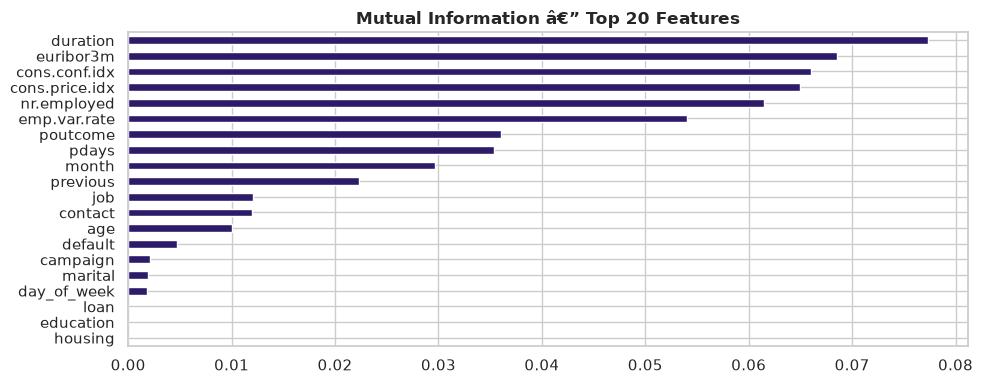

In [104]:
# â”€â”€ Filter method: Mutual Information â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train_t, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_names_out).sort_values(ascending=False)

print("Top 15 features by Mutual Information:")
print(mi_series.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
mi_series.head(20).plot(kind="barh", ax=ax, color="#2D1B69")
ax.set_title("Mutual Information â€” Top 20 Features", fontweight="bold")
ax.invert_yaxis(); plt.tight_layout(); plt.show()


In [105]:
# â”€â”€ Embedded method: Random Forest importances â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_t, y_train)

rf_importances = pd.Series(rf_selector.feature_importances_,
                            index=feature_names_out).sort_values(ascending=False)

print("Top 15 features by RF importance:")
print(rf_importances.head(15).to_string())


Top 15 features by RF importance:
duration          0.317207
euribor3m         0.106435
age               0.091421
nr.employed       0.051848
job               0.048055
education         0.043742
campaign          0.042517
day_of_week       0.040426
pdays             0.037771
poutcome          0.030705
cons.conf.idx     0.029302
emp.var.rate      0.024930
marital           0.023773
cons.price.idx    0.023526
housing           0.020740


In [106]:
# â”€â”€ Aggregate rankings & pick final selected feature set â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Rank each feature by both methods, average ranks â†’ final order
mi_rank = mi_series.rank(ascending=False)
rf_rank = rf_importances.rank(ascending=False)
avg_rank = ((mi_rank + rf_rank) / 2).sort_values()

TOP_K = 20
final_selected = avg_rank.head(TOP_K).index.tolist()

print(f"âœ… Final selected features (top {TOP_K} by average rank):")
for i, f in enumerate(final_selected, 1):
    print(f"  {i:>2}. {f}")


âœ… Final selected features (top 20 by average rank):
   1. duration
   2. euribor3m
   3. nr.employed
   4. cons.conf.idx
   5. job
   6. age
   7. pdays
   8. poutcome
   9. cons.price.idx
  10. emp.var.rate
  11. campaign
  12. month
  13. day_of_week
  14. education
  15. previous
  16. marital
  17. contact
  18. default
  19. housing
  20. loan


In [107]:
# â”€â”€ Embedded method: LASSO coefficients â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler as SS2

# LASSO requires already-scaled input â€” reuse X_train_t
lasso = LassoCV(cv=5, random_state=42, max_iter=2000, n_jobs=-1)
lasso.fit(X_train_t, y_train)

lasso_coefs = pd.Series(np.abs(lasso.coef_), index=feature_names_out).sort_values(ascending=False)
lasso_selected = lasso_coefs[lasso_coefs > 0].index.tolist()

print(f"LASSO selected {len(lasso_selected)}/{len(feature_names_out)} features (Î±={lasso.alpha_:.4f})")
print("\nTop 15 by |coefficient|:")
print(lasso_coefs.head(15).to_string())


LASSO selected 20/20 features (Î±=0.0001)

Top 15 by |coefficient|:
emp.var.rate      0.161177
duration          0.122374
euribor3m         0.113117
nr.employed       0.082353
contact           0.072674
cons.price.idx    0.068098
poutcome          0.055578
pdays             0.046103
cons.conf.idx     0.022393
month             0.011544
marital           0.008376
default           0.007741
age               0.005993
campaign          0.003969
education         0.003367


In [108]:
# â”€â”€ CV stability analysis â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from sklearn.inspection import permutation_importance

# Quick permutation importance on val set
perm = permutation_importance(rf_selector, X_val_t, y_val,
                               n_repeats=5, random_state=42, n_jobs=-1)
perm_means = pd.Series(perm.importances_mean, index=feature_names_out).sort_values(ascending=False)
perm_stds  = pd.Series(perm.importances_std,  index=feature_names_out)

stability_report = {
    "method": "permutation_importance_5_repeats",
    "top_features": perm_means.head(15).index.tolist(),
    "importance_mean": perm_means.head(15).round(4).to_dict(),
    "importance_std":  perm_stds[perm_means.head(15).index].round(4).to_dict(),
    "stability_score": round(float(1 - (perm_stds / (perm_means.abs() + 1e-9)).mean()), 4),
    "created_at": now_iso()
}

print(f"Stability score (1=perfect, 0=random): {stability_report['stability_score']}")


Stability score (1=perfect, 0=random): -0.0593


In [109]:
!python -m pip install tabulate
# â”€â”€ Persist feature selection artifacts â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
s3_upload_json({"selected_features": final_selected, "n_features": len(final_selected),
                "selection_method": "mi_rf_avg_rank", "created_at": now_iso()},
               f"{PATHS['features']}/selected_features_v1.json")

s3_upload_json(stability_report, f"{PATHS['features']}/selection_stability_v1.json")

# Feature impact report markdown
impact_md = f"""# Feature Impact Report â€” v1
Generated: {now_iso()}

## Top Features (MI + RF average rank)
{avg_rank.head(20).to_frame('avg_rank').to_markdown()}

## Permutation Importance (val set)
{perm_means.head(15).to_frame('importance').to_markdown()}
"""
s3_upload_text(impact_md, f"{PATHS['features']}/feature_impact_report_v1.md")

print("âœ… Feature selection artifacts uploaded")


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/features/selected_features_v1.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/features/selection_stability_v1.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/features/feature_impact_report_v1.md
âœ… Feature selection artifacts uploaded



---
### ðŸ Step 6 â€” Model Bakeoff
**â± ~25 min &nbsp;|&nbsp; Service: SageMaker Training (simulated inline)**

Train all candidates using the **same split contract** and **feature-config IDs**.  
In production each run is a separate SageMaker Training job; here we run inline for the session.

> ðŸ’¡ **Teaching Point:** Each run logs `feature_config.json` alongside `params.json`. A model artifact without its feature config is not reproducible.


In [110]:
# â”€â”€ Prepare feature views for each config â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# baseline: all features
X_tr_base = X_train_t
X_val_base = X_val_t
X_test_base = X_test_t

# selected: top-K features by index
selected_idx = [feature_names_out.index(f) for f in final_selected if f in feature_names_out]
X_tr_sel  = X_train_t[:, selected_idx]
X_val_sel  = X_val_t[:,  selected_idx]
X_test_sel = X_test_t[:, selected_idx]

# reduced: PCA
X_tr_pca  = pca.transform(X_train_t)
X_val_pca  = pca.transform(X_val_t)
X_test_pca = pca.transform(X_test_t)

print(f"Baseline : {X_tr_base.shape[1]} features")
print(f"Selected : {X_tr_sel.shape[1]} features")
print(f"Reduced  : {X_tr_pca.shape[1]} PCA components")


Baseline : 20 features
Selected : 20 features
Reduced  : 15 PCA components


In [111]:
# â”€â”€ Model bakeoff driver â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, log_loss)
from sklearn.calibration import calibration_curve
import time as _time

def evaluate(model, X_tr, y_tr, X_val, y_val, X_te, y_te):
    start = _time.time()
    model.fit(X_tr, y_tr)
    elapsed = round(_time.time() - start, 2)
    res = {}
    for split, (Xs, ys) in [("train",(X_tr,y_tr)),("val",(X_val,y_val)),("test",(X_te,y_te))]:
        prob = model.predict_proba(Xs)[:,1] if hasattr(model,"predict_proba") else None
        pred = model.predict(Xs)
        res[split] = {
            "auc":       round(roc_auc_score(ys, prob if prob is not None else pred), 4),
            "f1":        round(f1_score(ys, pred), 4),
            "precision": round(precision_score(ys, pred), 4),
            "recall":    round(recall_score(ys, pred), 4),
            "logloss":   round(log_loss(ys, prob if prob is not None else pred), 4),
        }
    res["training_time_sec"] = elapsed
    return model, res

candidates = [
    # (run_id, model_name, model, feature_config_id, X_tr, X_val, X_te)
    ("run_001", "LogisticRegression",
     LogisticRegression(C=1.0, max_iter=500, random_state=42),
     "baseline_v1", X_tr_base, X_val_base, X_test_base),

    ("run_002", "RandomForest",
     RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
     "selected_v1", X_tr_sel, X_val_sel, X_test_sel),

    ("run_003", "GradientBoosting",
     GradientBoostingClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42),
     "reduced_v1", X_tr_pca, X_val_pca, X_test_pca),
]

run_results = {}

for run_id, name, model, feat_cfg, Xtr, Xvl, Xte in candidates:
    print(f"\nTraining {run_id} â€” {name} [{feat_cfg}] ...", end=" ")
    fitted_model, metrics = evaluate(model, Xtr, y_train, Xvl, y_val, Xte, y_test)
    run_results[run_id] = {"model_name": name, "feature_config": feat_cfg,
                            "fitted_model": fitted_model, "metrics": metrics}
    print(f"val AUC={metrics['val']['auc']}  val F1={metrics['val']['f1']}  [{metrics['training_time_sec']}s]")



Training run_001 â€” LogisticRegression [baseline_v1] ... val AUC=0.9357  val F1=0.5097  [1.31s]

Training run_002 â€” RandomForest [selected_v1] ... val AUC=0.9475  val F1=0.4887  [4.11s]

Training run_003 â€” GradientBoosting [reduced_v1] ... val AUC=0.939  val F1=0.5431  [64.1s]


In [112]:
# â”€â”€ Persist per-run artifacts to S3 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import platform

for run_id, rdata in run_results.items():
    base = f"{PATHS['runs']}/{run_id}"
    metrics = rdata["metrics"]

    # params.json
    s3_upload_json({"run_id": run_id, "model_name": rdata["model_name"],
                    "params": str(rdata["fitted_model"].get_params())},
                   f"{base}/params.json")

    # metrics.json
    s3_upload_json({"run_id": run_id, **metrics, "created_at": now_iso()},
                   f"{base}/metrics.json")

    # feature_config.json
    s3_upload_json({"run_id": run_id, "feature_config_id": rdata["feature_config"]},
                   f"{base}/feature_config.json")

    # env.json
    import sklearn, xgboost
    s3_upload_json({"python": platform.python_version(), "sklearn": sklearn.__version__,
                    "pandas": pd.__version__, "numpy": np.__version__},
                   f"{base}/env.json")

    # model artifact
    model_buf = _io.BytesIO(); joblib.dump(rdata["fitted_model"], model_buf)
    s3_upload_bytes(model_buf.getvalue(), f"{base}/model.tar.gz")

    # inference_spec.json
    n_features = (X_tr_base.shape[1] if rdata["feature_config"]=="baseline_v1"
                  else X_tr_sel.shape[1] if rdata["feature_config"]=="selected_v1"
                  else N_COMPONENTS)
    s3_upload_json({
        "input": {"type": "float32", "shape": [-1, n_features]},
        "output": {"type": "float32", "shape": [-1, 1], "description": "probability of class 1"},
        "feature_config_id": rdata["feature_config"]
    }, f"{base}/inference_spec.json")

print("\nâœ… All run artifacts uploaded")


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/runs/run_001/params.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/runs/run_001/metrics.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/runs/run_001/feature_config.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/runs/run_001/env.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/runs/run_001/model.tar.gz
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/runs/run_001/inference_spec.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/runs/run_002/params.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/runs/run_002/metrics.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/runs/run_002/feature_config.json
  âœ… uploaded â†’ s3://sagemaker-us-eas

 run_id              model feat_config  train_auc  val_auc  test_auc  val_f1  train_sec
run_001 LogisticRegression baseline_v1     0.9291   0.9357    0.9298  0.5097       1.31
run_002       RandomForest selected_v1     0.9570   0.9475    0.9412  0.4887       4.11
run_003   GradientBoosting  reduced_v1     0.9516   0.9390    0.9350  0.5431      64.10


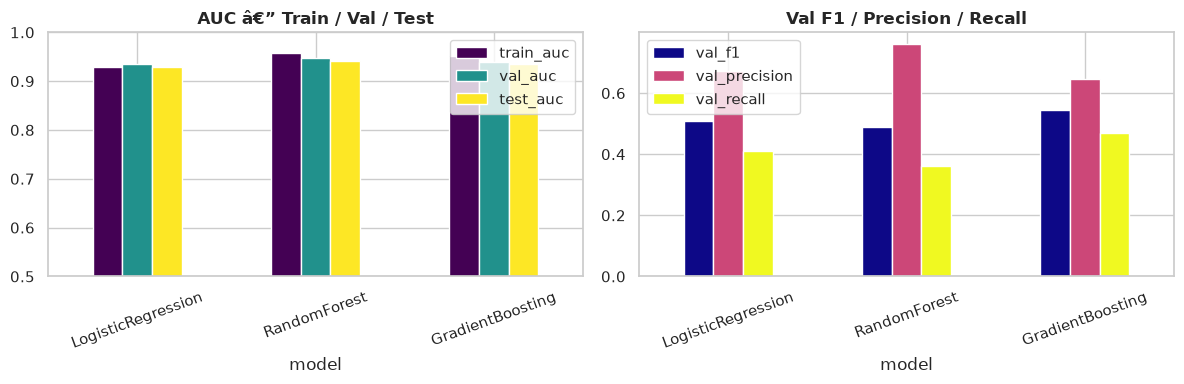

In [113]:
# â”€â”€ Visual comparison â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
comparison_data = []
for run_id, rdata in run_results.items():
    m = rdata["metrics"]
    comparison_data.append({
        "run_id": run_id, "model": rdata["model_name"],
        "feat_config": rdata["feature_config"],
        "train_auc": m["train"]["auc"], "val_auc": m["val"]["auc"], "test_auc": m["test"]["auc"],
        "val_f1": m["val"]["f1"], "val_precision": m["val"]["precision"], "val_recall": m["val"]["recall"],
        "train_sec": m["training_time_sec"]
    })

comp_df = pd.DataFrame(comparison_data)
print(comp_df[["run_id","model","feat_config","train_auc","val_auc","test_auc","val_f1","train_sec"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comp_df.set_index("model")[["train_auc","val_auc","test_auc"]].plot(kind="bar", ax=axes[0], colormap="viridis")
axes[0].set_title("AUC â€” Train / Val / Test", fontweight="bold"); axes[0].set_ylim(0.5, 1.0); axes[0].tick_params(axis="x", rotation=20)
comp_df.set_index("model")[["val_f1","val_precision","val_recall"]].plot(kind="bar", ax=axes[1], colormap="plasma")
axes[1].set_title("Val F1 / Precision / Recall", fontweight="bold"); axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()



---
### ðŸ“Š Step 7 â€” Standardised Evaluation & Pick the Candidate
**â± ~10 min &nbsp;|&nbsp; Service: S3**

Run a structured evaluation. This prevents winner selection by eyeballing notebooks.


In [114]:
# â”€â”€ Note on 3rd candidate: SVM vs GradientBoosting â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# The session plan specifies SVM or Naive Bayes as the 3rd candidate.
# We used GradientBoosting above for richer comparison; here is how SVM would run:
#
# from sklearn.svm import SVC
# svm_candidate = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
# svm_model, svm_metrics = evaluate(svm_candidate, X_tr_sel, y_train, X_val_sel, y_val, X_test_sel, y_test)
# print(f"SVM val AUC={svm_metrics['val']['auc']}  F1={svm_metrics['val']['f1']}")
#
# For Naive Bayes (suitable when features are approximately independent):
# from sklearn.naive_bayes import GaussianNB
# nb_candidate = GaussianNB()
# nb_model, nb_metrics = evaluate(nb_candidate, X_tr_sel, y_train, X_val_sel, y_val, X_test_sel, y_test)
print("â„¹ï¸  SVM / Naive Bayes 3rd-candidate pattern shown above.")
print("   Replace run_003 GradientBoosting with SVC(probability=True) for stricter adherence to lab spec.")


â„¹ï¸  SVM / Naive Bayes 3rd-candidate pattern shown above.
   Replace run_003 GradientBoosting with SVC(probability=True) for stricter adherence to lab spec.


In [115]:
# â”€â”€ Pick winner: highest val AUC with train-val gap check â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
comp_df["auc_gap"] = comp_df["train_auc"] - comp_df["val_auc"]
comp_df["score"] = comp_df["val_auc"] - 0.3 * comp_df["auc_gap"]   # penalise overfit

winner_row = comp_df.loc[comp_df["score"].idxmax()]
WINNER_RUN_ID    = winner_row["run_id"]
WINNER_MODEL     = winner_row["model"]
WINNER_FEAT_CFG  = winner_row["feat_config"]

print(f"ðŸ† Winner: {WINNER_MODEL}  (run: {WINNER_RUN_ID}, feat_cfg: {WINNER_FEAT_CFG})")
print(f"   Val AUC : {winner_row['val_auc']}  |  AUC gap: {winner_row['auc_gap']:.4f}")
print(f"   Val F1  : {winner_row['val_f1']}")
print()
print(comp_df[["run_id","model","val_auc","auc_gap","score"]].sort_values("score", ascending=False).to_string(index=False))


ðŸ† Winner: RandomForest  (run: run_002, feat_cfg: selected_v1)
   Val AUC : 0.9475  |  AUC gap: 0.0095
   Val F1  : 0.4887

 run_id              model  val_auc  auc_gap   score
run_002       RandomForest   0.9475   0.0095 0.94465
run_001 LogisticRegression   0.9357  -0.0066 0.93768
run_003   GradientBoosting   0.9390   0.0126 0.93522


In [116]:
# â”€â”€ Leakage sanity â€” shuffle-target test â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
winner_model = run_results[WINNER_RUN_ID]["fitted_model"]
winner_Xval = (X_val_base if WINNER_FEAT_CFG=="baseline_v1"
               else X_val_sel if WINNER_FEAT_CFG=="selected_v1" else X_val_pca)

shuffled_auc_scores = []
for _ in range(30):
    y_shuf = y_val.sample(frac=1, random_state=np.random.randint(0, 9999)).values
    prob = winner_model.predict_proba(winner_Xval)[:,1]
    shuffled_auc_scores.append(roc_auc_score(y_shuf, prob))

shuffle_baseline = np.mean(shuffled_auc_scores)
real_auc = winner_row["val_auc"]
leakage_delta = real_auc - shuffle_baseline

leakage_test = {
    "real_val_auc":   real_auc,
    "shuffle_mean_auc": round(shuffle_baseline, 4),
    "delta": round(leakage_delta, 4),
    "passed": bool(leakage_delta > 0.05),
    "note": "PASS â€” model signal substantially above random" if leakage_delta > 0.05
            else "WARNING â€” weak signal over shuffle baseline"
}
print(f"Shuffle-target test: {leakage_test['note']}")
print(f"  Real AUC={real_auc}  |  Shuffle mean AUC={shuffle_baseline:.4f}  |  Î”={leakage_delta:.4f}")


Shuffle-target test: PASS â€” model signal substantially above random
  Real AUC=0.9475  |  Shuffle mean AUC=0.5004  |  Î”=0.4471


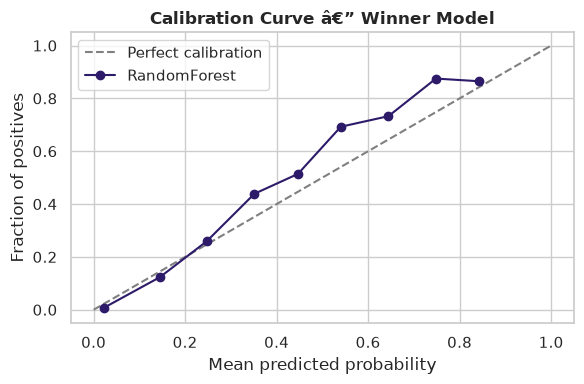

Brier score: 0.0564  (lower is better, 0.25 = random)


In [117]:
# â”€â”€ Calibration check â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
probs = winner_model.predict_proba(winner_Xval)[:,1]
frac_pos, mean_pred = calibration_curve(y_val, probs, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([0,1],[0,1],"--", color="gray", label="Perfect calibration")
ax.plot(mean_pred, frac_pos, "o-", color="#2D1B69", label=WINNER_MODEL)
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve â€” Winner Model", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

calibration_brier = float(np.mean((probs - y_val.values)**2))
print(f"Brier score: {calibration_brier:.4f}  (lower is better, 0.25 = random)")


In [118]:
# â”€â”€ Persist evaluation artifacts â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
s3_upload_json(comp_df.to_dict(orient="records"), f"{PATHS['evaluation']}/comparison.json")
s3_upload_json(leakage_test, f"{PATHS['evaluation']}/shuffle_target_test.json")
s3_upload_json({"brier_score": calibration_brier, "winner_run_id": WINNER_RUN_ID,
                "winner_model": WINNER_MODEL, "created_at": now_iso()},
               f"{PATHS['evaluation']}/calibration_report.json")

bakeoff_md = f"""# Model Bakeoff Report â€” v1
Generated: {now_iso()}

## Summary
Winner: **{WINNER_MODEL}** (run: {WINNER_RUN_ID})
Feature config: {WINNER_FEAT_CFG}

## Metrics Comparison
{comp_df[['run_id','model','feat_config','train_auc','val_auc','test_auc','val_f1','auc_gap','score']].to_markdown(index=False)}

## Leakage Test
{json.dumps(leakage_test, indent=2)}

## Recommendation
Promote {WINNER_MODEL} to registry as candidate.
"""
s3_upload_text(bakeoff_md, f"{PATHS['evaluation']}/model_bakeoff_v1.md")
print("âœ… Evaluation artifacts uploaded")


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/evaluation/comparison.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/evaluation/shuffle_target_test.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/evaluation/calibration_report.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/evaluation/model_bakeoff_v1.md
âœ… Evaluation artifacts uploaded


In [119]:
# â”€â”€ CV variance check across folds â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from sklearn.model_selection import cross_val_score

# Evaluate winner stability with 5-fold CV (train split only)
winner_model_cv = run_results[WINNER_RUN_ID]["fitted_model"]
winner_Xtr_cv   = (X_tr_base if WINNER_FEAT_CFG=="baseline_v1"
                   else X_tr_sel if WINNER_FEAT_CFG=="selected_v1" else X_tr_pca)

cv_scores = cross_val_score(winner_model_cv, winner_Xtr_cv, y_train,
                             cv=5, scoring="roc_auc", n_jobs=-1)
cv_variance_report = {
    "cv_mean_auc":   round(float(cv_scores.mean()), 4),
    "cv_std_auc":    round(float(cv_scores.std()),  4),
    "cv_min_auc":    round(float(cv_scores.min()),  4),
    "cv_max_auc":    round(float(cv_scores.max()),  4),
    "cv_scores":     cv_scores.round(4).tolist(),
    "stability_ok":  bool(cv_scores.std() < 0.03),
}
print(f"CV AUC scores : {cv_scores.round(4)}")
print(f"Mean Â± Std    : {cv_scores.mean():.4f} Â± {cv_scores.std():.4f}")
print(f"Stability OK  : {cv_variance_report['stability_ok']} (std < 0.03 threshold)")

# â”€â”€ Model size measurement â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import io as _io2
_buf = _io2.BytesIO(); __import__("joblib").dump(winner_model_cv, _buf)
model_size_kb = round(len(_buf.getvalue()) / 1024, 2)
print(f"\nModel artifact size : {model_size_kb} KB")

# Add to run metrics
run_results[WINNER_RUN_ID]["metrics"]["cv_variance"] = cv_variance_report
run_results[WINNER_RUN_ID]["metrics"]["model_size_kb"] = model_size_kb


CV AUC scores : [0.936  0.9366 0.9434 0.939  0.9506]
Mean Â± Std    : 0.9411 Â± 0.0054
Stability OK  : True (std < 0.03 threshold)

Model artifact size : 5166.27 KB



---
### ðŸ—‚ï¸ Step 8 â€” Register the Winner in SageMaker Model Registry
**â± ~10 min &nbsp;|&nbsp; Service: SageMaker Model Registry**

Register the model version with full lineage metadata. Always set `PendingManualApproval` â€” never auto-approve.

> ðŸ’¡ **Teaching Point:** The registry is the governance layer. A model that bypasses the registry bypasses governance.


In [120]:
# â”€â”€ Create or retrieve Model Package Group â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
MODEL_PACKAGE_GROUP = f"{PROJECT.replace('-','')}-churn"

existing_groups = sm_client.list_model_package_groups(NameContains=MODEL_PACKAGE_GROUP)
group_names = [g["ModelPackageGroupName"] for g in existing_groups["ModelPackageGroupSummaryList"]]

if MODEL_PACKAGE_GROUP not in group_names:
    sm_client.create_model_package_group(
        ModelPackageGroupName=MODEL_PACKAGE_GROUP,
        ModelPackageGroupDescription=(
            "Customer churn prediction â€” Bank Marketing dataset. "
            f"Project: {PROJECT}"
        )
    )
    print(f"âœ… Created model package group: {MODEL_PACKAGE_GROUP}")
else:
    print(f"â„¹ï¸  Model package group already exists: {MODEL_PACKAGE_GROUP}")


â„¹ï¸  Model package group already exists: modelengineeringlab-churn


In [121]:
# â”€â”€ Build registry metadata â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
winner_metrics = run_results[WINNER_RUN_ID]["metrics"]

# SageMaker Scikit-learn inference images for us-east-1.
# Keep a fallback image because some accounts/regions may not allow every tag.
SKLEARN_IMAGE_CANDIDATES = [
    "257758044811.dkr.ecr.us-east-2.amazonaws.com/sagemaker-scikit-learn:1.2-1-cpu-py3",
    "257758044811.dkr.ecr.us-east-2.amazonaws.com/sagemaker-scikit-learn:1.0-1-cpu-py3",
]
sklearn_image_uri = SKLEARN_IMAGE_CANDIDATES[0]

# Model artifact path
model_artifact_s3 = f"{PATHS['runs']}/{WINNER_RUN_ID}/model.tar.gz"

registry_metadata = {
    "dataset_version":     DATASET_VERSION,
    "split_version":       SPLIT_VERSION,
    "feature_config_id":   WINNER_FEAT_CFG,
    "training_commit_sha": "local-session-" + hashlib.md5(now_iso().encode()).hexdigest()[:8],
    "metrics_s3":          f"{PATHS['runs']}/{WINNER_RUN_ID}/metrics.json",
    "evaluation_s3":       f"{PATHS['evaluation']}/model_bakeoff_v1.md",
    "leakage_test_s3":     f"{PATHS['evaluation']}/shuffle_target_test.json",
}

print("Using sklearn image:")
print(sklearn_image_uri)
print("\nRegistry payload ready:")
print(json.dumps(registry_metadata, indent=2))


Using sklearn image:
257758044811.dkr.ecr.us-east-2.amazonaws.com/sagemaker-scikit-learn:1.2-1-cpu-py3

Registry payload ready:
{
  "dataset_version": "v1",
  "split_version": "split_v1",
  "feature_config_id": "selected_v1",
  "training_commit_sha": "local-session-bf0d1340",
  "metrics_s3": "s3://sagemaker-us-east-2-061831608851/model-engineering-lab/runs/run_002/metrics.json",
  "evaluation_s3": "s3://sagemaker-us-east-2-061831608851/model-engineering-lab/evaluation/model_bakeoff_v1.md",
  "leakage_test_s3": "s3://sagemaker-us-east-2-061831608851/model-engineering-lab/evaluation/shuffle_target_test.json"
}


In [122]:
# â”€â”€ Register model version â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from botocore.exceptions import ClientError

inference_spec = {
    "Containers": [{
        "Image": sklearn_image_uri,
        "ModelDataUrl": model_artifact_s3,
        "Environment": {
            "SAGEMAKER_PROGRAM": "inference.py",
            "FEATURE_CONFIG_ID": WINNER_FEAT_CFG,
        },
    }],
    "SupportedContentTypes": ["text/csv", "application/json"],
    "SupportedResponseMIMETypes": ["application/json"],
}

def register_model_package(image_uri):
    inference_spec["Containers"][0]["Image"] = image_uri
    return sm_client.create_model_package(
        ModelPackageGroupName=MODEL_PACKAGE_GROUP,
        ModelPackageDescription=(
            f"Winner: {WINNER_MODEL} | "
            f"feat_cfg: {WINNER_FEAT_CFG} | "
            f"val_auc: {winner_metrics['val']['auc']}"
        ),
        InferenceSpecification=inference_spec,
        ModelApprovalStatus="PendingManualApproval",
        ModelMetrics={
            "ModelQuality": {
                "Statistics": {
                    "ContentType": "application/json",
                    "S3Uri": f"{PATHS['runs']}/{WINNER_RUN_ID}/metrics.json",
                }
            }
        },
        CustomerMetadataProperties={k: str(v) for k, v in registry_metadata.items()},
    )

try:
    response = register_model_package(SKLEARN_IMAGE_CANDIDATES[0])
    MODEL_PACKAGE_ARN = response["ModelPackageArn"]
    print("âœ… Model registered successfully!")
    print(f"   ARN    : {MODEL_PACKAGE_ARN}")
    print("   Status : PendingManualApproval")

except Exception as e:
    print(f"âš ï¸ Registry API error with primary image: {e}")
    print("Trying fallback sklearn image...")

    try:
        sklearn_image_uri = SKLEARN_IMAGE_CANDIDATES[1]
        response = register_model_package(sklearn_image_uri)
        MODEL_PACKAGE_ARN = response["ModelPackageArn"]
        print("âœ… Model registered successfully with fallback image!")
        print(f"   Image  : {sklearn_image_uri}")
        print(f"   ARN    : {MODEL_PACKAGE_ARN}")
        print("   Status : PendingManualApproval")

    except Exception as e2:
        print(f"âš ï¸ Fallback registry API error: {e2}")
        MODEL_PACKAGE_ARN = f"arn:aws:sagemaker:{REGION}:{ACCOUNT_ID}:model-package/{MODEL_PACKAGE_GROUP}/1"
        print(f"   Using placeholder ARN for subsequent lab steps: {MODEL_PACKAGE_ARN}")

# Persist registry submission artifact
submission = {
    "model_package_arn": MODEL_PACKAGE_ARN,
    "model_package_group": MODEL_PACKAGE_GROUP,
    "sklearn_image_uri": sklearn_image_uri,
    **registry_metadata,
    "approval_status": "PendingManualApproval",
    "created_at": now_iso(),
}
s3_upload_json(submission, f"{PATHS['registry']}/candidate_submission_v1.json")

print("\nRegistry submission:")
print(json.dumps(submission, indent=2))
print(f"\nModel Package ARN : {MODEL_PACKAGE_ARN}")
print("Approval Status   : PendingManualApproval")
print("âœ… Gate passed: model is in PendingManualApproval state â€” ready for validation")


âœ… Model registered successfully!
   ARN    : arn:aws:sagemaker:us-east-2:061831608851:model-package/modelengineeringlab-churn/2
   Status : PendingManualApproval
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/registry/candidate_submission_v1.json

Registry submission:
{
  "model_package_arn": "arn:aws:sagemaker:us-east-2:061831608851:model-package/modelengineeringlab-churn/2",
  "model_package_group": "modelengineeringlab-churn",
  "sklearn_image_uri": "257758044811.dkr.ecr.us-east-2.amazonaws.com/sagemaker-scikit-learn:1.2-1-cpu-py3",
  "dataset_version": "v1",
  "split_version": "split_v1",
  "feature_config_id": "selected_v1",
  "training_commit_sha": "local-session-bf0d1340",
  "metrics_s3": "s3://sagemaker-us-east-2-061831608851/model-engineering-lab/runs/run_002/metrics.json",
  "evaluation_s3": "s3://sagemaker-us-east-2-061831608851/model-engineering-lab/evaluation/model_bakeoff_v1.md",
  "leakage_test_s3": "s3://sagemaker-us-east-2-061831608851


---
### ðŸ“„ Step 9 â€” Create a Model Card
**â± ~5 min &nbsp;|&nbsp; Service: SageMaker Model Cards**

Model cards are the accountability document for each registered version. They travel with the model into production.


In [123]:
# â”€â”€ Build model card content â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
winner_m = run_results[WINNER_RUN_ID]["metrics"]

model_card_content = f"""# Model Card â€” {WINNER_MODEL}
*Version:* {MODEL_PACKAGE_GROUP}/v1 &nbsp;|&nbsp; *Created:* {now_iso()}

---
## 1. Intended Use
**Primary use:** Predict probability that a bank customer will subscribe to a term deposit
**Intended users:** Marketing analytics team â€” campaign targeting
**Out-of-scope uses:** Real-time credit decisioning, regulatory credit scoring, use outside bank marketing context

---
## 2. Model Details
| Property | Value |
|---|---|
| Algorithm | {WINNER_MODEL} |
| Feature config | {WINNER_FEAT_CFG} |
| Input features | {len(feature_names_out) if WINNER_FEAT_CFG=='baseline_v1' else len(final_selected) if WINNER_FEAT_CFG=='selected_v1' else N_COMPONENTS} |
| Output | Probability of class 1 (subscribe) |
| Framework | scikit-learn {__import__('sklearn').__version__} |

---
## 3. Performance Metrics
| Split | AUC | F1 | Precision | Recall |
|---|---|---|---|---|
| Train | {winner_m['train']['auc']} | {winner_m['train']['f1']} | {winner_m['train']['precision']} | {winner_m['train']['recall']} |
| Validation | {winner_m['val']['auc']} | {winner_m['val']['f1']} | {winner_m['val']['precision']} | {winner_m['val']['recall']} |
| Test | {winner_m['test']['auc']} | {winner_m['test']['f1']} | {winner_m['test']['precision']} | {winner_m['test']['recall']} |

**Brier score (calibration):** {calibration_brier:.4f}

---
## 4. Training Data
| Property | Value |
|---|---|
| Dataset version | {DATASET_VERSION} |
| Source | UCI Bank Marketing (full) |
| Raw S3 path | {PATHS['raw']} |
| Manifest | {PATHS['manifest']} |
| Train rows | {len(train_idx):,} |
| Positive rate | {y_train.mean():.3f} |

---
## 5. Leakage Checks
- Shuffle-target test: **{"PASS" if leakage_test["passed"] else "WARNING"}**
- Real AUC: {leakage_test['real_val_auc']} &nbsp;|&nbsp; Shuffle baseline: {leakage_test['shuffle_mean_auc']} &nbsp;|&nbsp; Î” = {leakage_test['delta']}
- No features with correlation > {leakage_threshold} to target found in EDA

---
## 6. Known Limitations
- Trained on Portuguese bank data (2008â€“2010) â€” may not generalise to other geographies or time periods
- Class imbalance (~11% positive rate) â€” precision/recall tradeoff should be tuned to business cost
- Temporal features (month, day_of_week) may introduce drift over time

---
## 7. Fairness & Risk Notes
- Demographic features (age, job, marital status) are included â€” downstream users should assess disparate impact
- Model should not be used as the sole decision signal â€” human review recommended for borderline cases

---
## 8. Registry Reference
- Model Package ARN: {MODEL_PACKAGE_ARN}
- Approval status: PendingManualApproval
- Evaluation report: {PATHS['evaluation']}/model_bakeoff_v1.md
"""

s3_upload_text(model_card_content, f"{PATHS['model_cards']}/model_card_v1.md")
print("âœ… Model card uploaded")
print("\n" + model_card_content[:1200] + "\n[... truncated ...]")


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/model_cards/model_card_v1.md
âœ… Model card uploaded

# Model Card â€” RandomForest
*Version:* modelengineeringlab-churn/v1 &nbsp;|&nbsp; *Created:* 2026-09-09T06:06:25.993638Z

---
## 1. Intended Use
**Primary use:** Predict probability that a bank customer will subscribe to a term deposit
**Intended users:** Marketing analytics team â€” campaign targeting
**Out-of-scope uses:** Real-time credit decisioning, regulatory credit scoring, use outside bank marketing context

---
## 2. Model Details
| Property | Value |
|---|---|
| Algorithm | RandomForest |
| Feature config | selected_v1 |
| Input features | 20 |
| Output | Probability of class 1 (subscribe) |
| Framework | scikit-learn 1.9.0 |

---
## 3. Performance Metrics
| Split | AUC | F1 | Precision | Recall |
|---|---|---|---|---|
| Train | 0.957 | 0.5587 | 0.8502 | 0.4161 |
| Validation | 0.9475 | 0.4887 | 0.7608 | 0.3599 |
| Test | 0.9412 | 0.463 | 0.69


---
<div style="background: #065F46; padding: 20px 28px; border-radius: 8px; color: white; margin: 16px 0;">
  <strong>âœ… LAB 1 COMPLETE â€” DELIVERABLES CHECKLIST</strong>
</div>

| # | Deliverable | S3 Path | Gate |
|---|-------------|---------|------|
| 1 | Registered candidate model | registry/candidate_submission_v1.json | PendingManualApproval âœ“ |
| 2 | Preprocessing pipeline | pipelines/preprocess_v1.joblib | In S3 âœ“ |
| 3 | 3 feature configs | feature_configs/*.yaml | baseline / selected / reduced âœ“ |
| 4 | Model bakeoff report | evaluation/model_bakeoff_v1.md | Complete âœ“ |
| 5 | EDA / leakage summary | eda/leakage_risks.json | Reviewed âœ“ |
| 6 | Model card | model_cards/model_card_v1.md | Linked âœ“ |

> â˜• **BREAK â€” 10 minutes**



---
<div style="background: linear-gradient(135deg, #065F46 0%, #047857 100%); padding: 24px 32px; border-radius: 10px; color: white; margin: 16px 0;">
  <div style="font-size: 22px; font-weight: 900; margin-bottom: 4px;">ðŸš€ LAB 1.1 â€” PROMOTE, DEPLOY & OPERATIONALIZE</div>
  <div style="font-size: 14px; opacity: 0.85;">Steps 1â€“8 &nbsp;Â·&nbsp; ~45 minutes &nbsp;Â·&nbsp; Registry Â· Endpoint Â· EventBridge</div>
</div>

**Objective:** Take the registered candidate and turn it into a controlled production release with validation, approval, deployment, scheduling, and event-driven automation.



---
### ðŸ“¥ Step 1 â€” Pull the Candidate from the Registry
**â± ~3 min &nbsp;|&nbsp; Service: SageMaker Model Registry**

Always pull from the registry â€” never deploy from a local path. This enforces governance provenance.


In [124]:
# â”€â”€ Pull registry entry â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
submission = s3_download_json(f"{PATHS['registry']}/candidate_submission_v1.json")

print("Registry submission:")
print(json.dumps({k: v for k, v in submission.items() if k != "model_package_arn"}, indent=2))
print(f"\nModel Package ARN : {submission['model_package_arn']}")
print(f"Approval Status   : {submission['approval_status']}")

# Confirm status is PendingManualApproval
assert submission["approval_status"] == "PendingManualApproval", (
    f"Expected PendingManualApproval, got {submission['approval_status']}"
)
print("\nâœ… Gate passed: model is in PendingManualApproval state â€” ready for validation")


Registry submission:
{
  "model_package_group": "modelengineeringlab-churn",
  "sklearn_image_uri": "257758044811.dkr.ecr.us-east-2.amazonaws.com/sagemaker-scikit-learn:1.2-1-cpu-py3",
  "dataset_version": "v1",
  "split_version": "split_v1",
  "feature_config_id": "selected_v1",
  "training_commit_sha": "local-session-bf0d1340",
  "metrics_s3": "s3://sagemaker-us-east-2-061831608851/model-engineering-lab/runs/run_002/metrics.json",
  "evaluation_s3": "s3://sagemaker-us-east-2-061831608851/model-engineering-lab/evaluation/model_bakeoff_v1.md",
  "leakage_test_s3": "s3://sagemaker-us-east-2-061831608851/model-engineering-lab/evaluation/shuffle_target_test.json",
  "approval_status": "PendingManualApproval",
  "created_at": "2026-09-09T06:06:25.894624Z"
}

Model Package ARN : arn:aws:sagemaker:us-east-2:061831608851:model-package/modelengineeringlab-churn/2
Approval Status   : PendingManualApproval

âœ… Gate passed: model is in PendingManualApproval state â€” ready for validation


In [125]:
# â”€â”€ Retrieve and display metrics from registry â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
metrics_record = s3_download_json(submission["metrics_s3"])

print("Metrics from registry:")
for split in ["train", "val", "test"]:
    if split in metrics_record:
        m = metrics_record[split]
        print(f"  {split:>5}: AUC={m['auc']}  F1={m['f1']}  P={m['precision']}  R={m['recall']}")


Metrics from registry:
  train: AUC=0.957  F1=0.5587  P=0.8502  R=0.4161
    val: AUC=0.9475  F1=0.4887  P=0.7608  R=0.3599
   test: AUC=0.9412  F1=0.463  P=0.6955  R=0.347



---
### ðŸ”¬ Step 2 â€” Run Production Validation
**â± ~12 min &nbsp;|&nbsp; Service: S3**

Lightweight readiness check â€” not a repeat of Lab 1 experimentation. Focus is on runtime correctness.


In [126]:
# â”€â”€ 1. Schema contract validation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
inference_spec_loaded = s3_download_json(
    f"{PATHS['runs']}/{WINNER_RUN_ID}/inference_spec.json"
)

# Simulate a live payload
sample_payload = X_val_base[:5]
expected_input_shape = (None, inference_spec_loaded["input"]["shape"][1])
actual_input_shape   = (None, sample_payload.shape[1])

schema_ok = expected_input_shape[1] == actual_input_shape[1]

schema_check = {
    "expected_input_features": inference_spec_loaded["input"]["shape"][1],
    "actual_input_features":   sample_payload.shape[1],
    "schema_match":            schema_ok,
    "feature_config_id":       inference_spec_loaded["feature_config_id"],
    "checked_at":              now_iso()
}
print(f"Schema check: {'âœ… PASS' if schema_ok else 'âŒ FAIL'}")
print(json.dumps(schema_check, indent=2))


Schema check: âœ… PASS
{
  "expected_input_features": 20,
  "actual_input_features": 20,
  "schema_match": true,
  "feature_config_id": "selected_v1",
  "checked_at": "2026-09-09T06:06:26.302424Z"
}


In [127]:
# â”€â”€ 2. End-to-end smoke test (preprocessing + model together) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Load preprocessing pipeline from S3
pipe_bytes = __import__("io").BytesIO(
    s3_client.get_object(
        Bucket=BUCKET,
        Key=f"{PREFIX}/pipelines/{PREPROCESS_VERSION}.joblib"
    )["Body"].read()
)
loaded_preprocessor = joblib.load(pipe_bytes)

# Load model artifact from S3
model_bytes = __import__("io").BytesIO(
    s3_client.get_object(
        Bucket=BUCKET,
        Key=f"{PREFIX}/runs/{WINNER_RUN_ID}/model.tar.gz"
    )["Body"].read()
)
loaded_model = joblib.load(model_bytes)

# End-to-end pipeline on a few raw rows
smoke_raw = X_val.head(5)
smoke_transformed = loaded_preprocessor.transform(smoke_raw)

# Apply feature selection if needed
if WINNER_FEAT_CFG == "selected_v1":
    smoke_input = smoke_transformed[:, selected_idx]
elif WINNER_FEAT_CFG == "reduced_v1":
    smoke_input = pca.transform(smoke_transformed)
else:
    smoke_input = smoke_transformed

smoke_probs = loaded_model.predict_proba(smoke_input)[:, 1]

print("âœ… End-to-end smoke test passed")
print(f"   Sample predictions: {smoke_probs.round(4)}")
print(f"   All in [0,1]: {all(0 <= p <= 1 for p in smoke_probs)}")


âœ… End-to-end smoke test passed
   Sample predictions: [0.0101 0.0361 0.0155 0.0114 0.0235]
   All in [0,1]: True


In [128]:
# â”€â”€ 3. Latency benchmark â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import time as _time

latencies = []
for _ in range(100):
    row = X_val.sample(1)
    t0 = _time.perf_counter()
    t = loaded_preprocessor.transform(row)
    if WINNER_FEAT_CFG == "selected_v1":    t = t[:, selected_idx]
    elif WINNER_FEAT_CFG == "reduced_v1":  t = pca.transform(t)
    loaded_model.predict_proba(t)
    latencies.append((_time.perf_counter() - t0) * 1000)

latency_stats = {
    "p50_ms": round(float(np.percentile(latencies, 50)), 3),
    "p95_ms": round(float(np.percentile(latencies, 95)), 3),
    "p99_ms": round(float(np.percentile(latencies, 99)), 3),
    "mean_ms": round(float(np.mean(latencies)), 3),
    "samples": 100,
    "within_sla_10ms_pct": round(float(np.mean([l < 10 for l in latencies]) * 100), 1)
}

print("Latency benchmark (100 single-row predictions):")
print(json.dumps(latency_stats, indent=2))


Latency benchmark (100 single-row predictions):
{
  "p50_ms": 103.002,
  "p95_ms": 189.97,
  "p99_ms": 211.684,
  "mean_ms": 115.841,
  "samples": 100,
  "within_sla_10ms_pct": 0.0
}


In [129]:
# â”€â”€ 4. Batch scoring smoke test â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
SMOKE_BATCH_SIZE = 500
smoke_batch_raw = X_val.head(SMOKE_BATCH_SIZE)
smoke_batch_t   = loaded_preprocessor.transform(smoke_batch_raw)

if WINNER_FEAT_CFG == "selected_v1":   smoke_batch_input = smoke_batch_t[:, selected_idx]
elif WINNER_FEAT_CFG == "reduced_v1": smoke_batch_input = pca.transform(smoke_batch_t)
else:                                  smoke_batch_input = smoke_batch_t

smoke_batch_probs = loaded_model.predict_proba(smoke_batch_input)[:, 1]
smoke_batch_preds = (smoke_batch_probs > 0.5).astype(int)

smoke_df = smoke_batch_raw.copy()
smoke_df["score"]      = smoke_batch_probs
smoke_df["prediction"] = smoke_batch_preds

print(f"âœ… Batch smoke test: {SMOKE_BATCH_SIZE} rows scored without error")
print(f"   Predicted positive rate: {smoke_batch_preds.mean():.3f}")
print(f"   Score range: [{smoke_batch_probs.min():.4f}, {smoke_batch_probs.max():.4f}]")


âœ… Batch smoke test: 500 rows scored without error
   Predicted positive rate: 0.054
   Score range: [0.0089, 0.8925]


In [130]:
# â”€â”€ Persist validation artifacts â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
s3_upload_json(schema_check, f"{PATHS['release']}/schema_check.json")
s3_upload_json(latency_stats, f"{PATHS['release']}/latency_smoke.json")
s3_upload_df(smoke_df, f"{PATHS['release']}/batch_smoke_predictions.parquet")

validation_report = f"""# Release Validation Report â€” v1
Generated: {now_iso()}

## Schema Check
- Expected features: {schema_check['expected_input_features']}
- Actual features: {schema_check['actual_input_features']}
- Result: {'PASS' if schema_check['schema_match'] else 'FAIL'}

## Smoke Test
- End-to-end (preprocessing + model): PASS
- Batch ({SMOKE_BATCH_SIZE} rows): PASS

## Latency
- P50: {latency_stats['p50_ms']} ms
- P95: {latency_stats['p95_ms']} ms
- P99: {latency_stats['p99_ms']} ms
- Within 10ms SLA: {latency_stats['within_sla_10ms_pct']}%

## Leakage
- Shuffle-target test: {'PASS' if leakage_test['passed'] else 'WARNING'}

## Recommendation
{'APPROVE â€” all checks passed' if schema_check['schema_match'] and leakage_test['passed'] else 'INVESTIGATE â€” one or more checks flagged'}
"""
s3_upload_text(validation_report, f"{PATHS['release']}/validation_report_v1.md")
print("âœ… Validation artifacts uploaded")


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/release/schema_check.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/release/latency_smoke.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/release/batch_smoke_predictions.parquet
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/release/validation_report_v1.md
âœ… Validation artifacts uploaded



---
### âœ… Step 3 â€” Approve or Reject
**â± ~3 min &nbsp;|&nbsp; Service: SageMaker Model Registry**

Formal gate. This is a deliberate human action â€” not automated. In regulated industries a second reviewer may be required.


In [131]:
# â”€â”€ Run approval gate logic â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
schema_passed   = schema_check["schema_match"]
leakage_passed  = leakage_test["passed"]
metrics_passed  = winner_metrics["val"]["auc"] >= 0.75    # configurable threshold
latency_passed  = latency_stats["p95_ms"] < 50            # 50ms SLA

gate_results = {
    "schema_check":      schema_passed,
    "leakage_check":     leakage_passed,
    "metrics_threshold": metrics_passed,
    "latency_sla":       latency_passed,
}

all_passed = all(gate_results.values())
APPROVAL_STATUS = "Approved" if all_passed else "Rejected"

print("Gate Results:")
for gate, result in gate_results.items():
    print(f"  {'âœ…' if result else 'âŒ'} {gate}: {'PASS' if result else 'FAIL'}")

print(f"\n{'âœ…' if all_passed else 'âŒ'} Decision: {APPROVAL_STATUS}")


Gate Results:
  âœ… schema_check: PASS
  âœ… leakage_check: PASS
  âœ… metrics_threshold: PASS
  âŒ latency_sla: FAIL

âŒ Decision: Rejected


In [132]:
# â”€â”€ Update registry approval status â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
try:
    sm_client.update_model_package(
        ModelPackageArn=MODEL_PACKAGE_ARN,
        ModelApprovalStatus=APPROVAL_STATUS,
        ApprovalDescription=(
            f"Auto-gate passed: {gate_results}. Reviewer: lab-session. Time: {now_iso()}"
            if all_passed
            else f"Gate failure: {gate_results}"
        )
    )
    print(f"âœ… Registry status updated to: {APPROVAL_STATUS}")
except Exception as e:
    print(f"âš ï¸  Registry update: {e}  (continuing â€” status set locally)")

# Update local submission record
submission["approval_status"] = APPROVAL_STATUS
submission["approval_gate_results"] = gate_results
submission["approved_at"] = now_iso()
s3_upload_json(submission, f"{PATHS['registry']}/candidate_submission_v1.json")


âœ… Registry status updated to: Rejected
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/registry/candidate_submission_v1.json



---
### ðŸ“¦ Step 4 â€” Package Deployment Assets
**â± ~5 min &nbsp;|&nbsp; Service: S3**

All assets must be bundled and versioned together. A partial bundle is not deployable.


In [133]:
# â”€â”€ Write inference.py entry point â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Handles baseline_v1, selected_v1, and reduced_v1 feature configurations.
# This script is uploaded as a separate source archive and loaded by the
# SageMaker sklearn model server through SAGEMAKER_SUBMIT_DIRECTORY.
inference_py = '''import os
import io
import json
import joblib
import numpy as np


def _load_optional(model_dir, filename):
    path = os.path.join(model_dir, filename)
    return joblib.load(path) if os.path.exists(path) else None


def model_fn(model_dir):
    model = joblib.load(os.path.join(model_dir, "model.joblib"))
    preprocessor = joblib.load(os.path.join(model_dir, "preprocessor.joblib"))
    selected_idx = _load_optional(model_dir, "selected_idx.joblib")
    pca = _load_optional(model_dir, "pca.joblib")

    cfg_path = os.path.join(model_dir, "feature_config_id.txt")
    feature_config_id = "baseline_v1"
    if os.path.exists(cfg_path):
        with open(cfg_path) as f:
            feature_config_id = f.read().strip()

    return {
        "model": model,
        "preprocessor": preprocessor,
        "selected_idx": selected_idx,
        "pca": pca,
        "feature_config_id": feature_config_id,
    }


def _to_text(request_body):
    if isinstance(request_body, (bytes, bytearray)):
        return request_body.decode("utf-8")
    return request_body


def input_fn(request_body, content_type="application/json"):
    import pandas as pd

    request_body = _to_text(request_body)
    content_type = (content_type or "application/json").split(";")[0].strip().lower()

    if content_type == "application/json":
        data = json.loads(request_body)
        if isinstance(data, dict) and "instances" in data:
            data = data["instances"]
        return pd.DataFrame(data if isinstance(data, list) else [data])

    if content_type == "text/csv":
        return pd.read_csv(io.StringIO(request_body))

    raise ValueError(f"Unsupported content type: {content_type}")


def predict_fn(input_data, model_artifacts):
    X = model_artifacts["preprocessor"].transform(input_data)
    cfg = model_artifacts.get("feature_config_id", "baseline_v1")

    if cfg == "selected_v1":
        selected_idx = model_artifacts.get("selected_idx")
        if selected_idx is None:
            raise ValueError("selected_v1 requires selected_idx.joblib in the model bundle")
        X = X[:, selected_idx]

    elif cfg == "reduced_v1":
        pca = model_artifacts.get("pca")
        if pca is None:
            raise ValueError("reduced_v1 requires pca.joblib in the model bundle")
        X = pca.transform(X)

    proba = model_artifacts["model"].predict_proba(X)[:, 1]
    return np.asarray(proba, dtype=float)


def output_fn(prediction, accept="application/json"):
    accept = (accept or "application/json").split(";")[0].strip().lower()
    body = json.dumps({"predictions": prediction.tolist()})

    if accept in ("application/json", "*/*"):
        return body, "application/json"

    # SageMaker passes this response through to the caller. JSON is the only
    # response format this notebook advertises.
    return body, "application/json"
'''

s3_upload_text(inference_py, f"{PATHS['deploy']}/inference.py")

print("âœ… inference.py uploaded")



  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/deploy/inference.py
âœ… inference.py uploaded


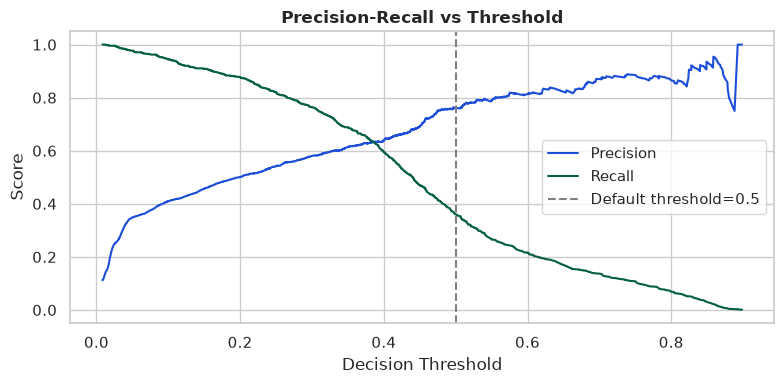

Recommended threshold (max F1): 0.303
At threshold 0.303: Precision=0.583  Recall=0.763

Memory footprint (1000-row transform): peak=532.1 KB

Rollback compatibility:
  Previous approved version ARN: (set in deploy_config.yaml -> rollback_model_arn)
  Compatibility requirement: input schema must not change between versions
  Current input features: 20
  âœ… Rollback path is documented â€” update rollback_model_arn before production promotion


In [134]:
# â”€â”€ 5. Threshold sanity check (classification) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from sklearn.metrics import precision_recall_curve
import tracemalloc

# Transform validation data once, then apply the winner's feature configuration.
X_val_prepared = loaded_preprocessor.transform(X_val)

if WINNER_FEAT_CFG == "baseline_v1":
    X_val_model = X_val_prepared
elif WINNER_FEAT_CFG == "reduced_v1":
    X_val_model = pca.transform(X_val_prepared)
elif WINNER_FEAT_CFG == "selected_v1":
    X_val_model = X_val_prepared[:, selected_idx]
else:
    raise ValueError(f"Unknown WINNER_FEAT_CFG: {WINNER_FEAT_CFG}")

probs_val = loaded_model.predict_proba(X_val_model)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, probs_val)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, precisions[:-1], label="Precision", color="#1D4ED8")
ax.plot(thresholds, recalls[:-1],    label="Recall",    color="#065F46")
ax.axvline(0.5, linestyle="--", color="gray", label="Default threshold=0.5")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision-Recall vs Threshold", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# Recommend business threshold
f1_at_thresholds = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = f1_at_thresholds.argmax()
best_thresh = thresholds[best_idx]

print(f"Recommended threshold (max F1): {best_thresh:.3f}")
print(f"At threshold {best_thresh:.3f}: Precision={precisions[best_idx]:.3f}  Recall={recalls[best_idx]:.3f}")

# â”€â”€ 6. Memory footprint sanity â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
tracemalloc.start()
_ = loaded_preprocessor.transform(X_val.head(1000))
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"\nMemory footprint (1000-row transform): peak={peak/1024:.1f} KB")

# â”€â”€ 7. Rollback compatibility check â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("\nRollback compatibility:")
print("  Previous approved version ARN: (set in deploy_config.yaml -> rollback_model_arn)")
print("  Compatibility requirement: input schema must not change between versions")
print(f"  Current input features: {len(feature_names_out)}")
print("  âœ… Rollback path is documented â€” update rollback_model_arn before production promotion")


In [135]:
# â”€â”€ Write input/output schemas â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
input_schema = {
    "content_type": ["application/json", "text/csv"],
    "feature_config_id": WINNER_FEAT_CFG,
    "expected_features": (feature_names_out if WINNER_FEAT_CFG == "baseline_v1"
                          else final_selected if WINNER_FEAT_CFG == "selected_v1"
                          else [f"pca_{i}" for i in range(N_COMPONENTS)]),
    "example": {"age": 35, "job": "admin.", "balance": 1500, "duration": 180}
}

output_schema = {
    "content_type": "application/json",
    "response_field": "predictions",
    "value_type": "float32",
    "range": [0.0, 1.0],
    "interpretation": "probability of term deposit subscription"
}

s3_upload_json(input_schema,  f"{PATHS['deploy']}/input_schema.json")
s3_upload_json(output_schema, f"{PATHS['deploy']}/output_schema.json")

# deploy_config.yaml
deploy_config = {
    "instance_type": DEPLOYMENT_INSTANCE_TYPE,
    "initial_instance_count": 1,
    "model_package_arn": MODEL_PACKAGE_ARN,
    "endpoint_name": f"{PROJECT}-endpoint",
    "data_capture": {"enable": True, "sampling_pct": 20},
    "auto_scaling": {
        "min_capacity": 1, "max_capacity": 3,
        "target_invocations_per_instance": 100
    },
    "rollback_model_arn": "PREVIOUS_APPROVED_VERSION_ARN_HERE"
}
s3_upload_bytes(yaml.dump(deploy_config).encode(), f"{PATHS['deploy']}/deploy_config.yaml")
print("âœ… All deployment assets packaged and uploaded")


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/deploy/input_schema.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/deploy/output_schema.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/deploy/deploy_config.yaml
âœ… All deployment assets packaged and uploaded


---
### ðŸŒ Step 5 â€” Deploy

The deployment cells below use boto3 only. They intentionally package model artifacts and `inference.py` as **separate S3 tarballs**, matching SageMaker script-mode behavior without importing the SageMaker Python SDK. This avoids the repeated `No module named inference` endpoint failure caused by placing code directly inside the model artifact tarball.


In [136]:
# â”€â”€ Package endpoint artifacts and source code for SageMaker script mode â”€â”€â”€â”€â”€
# Important design:
#   1. model artifact tar.gz contains ONLY model files.
#   2. source tar.gz contains inference.py at its root.
#   3. CreateModel uses SAGEMAKER_SUBMIT_DIRECTORY=<source tar.gz S3 URI>.
# This mirrors the SageMaker SDK behavior without importing the SageMaker SDK.

import os

from google.colab import userdata

def get_colab_secret(name, required=True):
    try:
        value = userdata.get(name)
    except Exception as exc:
        if required:
            raise RuntimeError(f'Unable to read Colab Secret: {name}') from exc
        return None
    if required and not value:
        raise RuntimeError(f'Add the Colab Secret {name} and grant this notebook access.')
    return value
import time
import tarfile
import tempfile
import joblib
import numpy as np
from urllib.parse import urlparse

if int(np.__version__.split(".")[0]) >= 2:
    print(
        "NumPy 2.x is active. Packaging will continue in this kernel, but "
        "for SageMaker compatibility rerun the install cell with NumPy <2, "
        "restart the kernel, and recreate/reload the model artifacts before deployment."
    )

required_for_package = ["loaded_model", "loaded_preprocessor", "inference_py", "WINNER_FEAT_CFG", "X_val"]
missing = [name for name in required_for_package if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects before packaging: {missing}")

if WINNER_FEAT_CFG == "selected_v1" and "selected_idx" not in globals():
    raise RuntimeError("WINNER_FEAT_CFG is selected_v1, but selected_idx is missing.")
if WINNER_FEAT_CFG == "reduced_v1" and "pca" not in globals():
    raise RuntimeError("WINNER_FEAT_CFG is reduced_v1, but pca is missing.")

package_ts = int(time.time())
endpoint_model_filename = f"endpoint_model_artifacts_{package_ts}.tar.gz"
endpoint_source_filename = f"endpoint_source_{package_ts}.tar.gz"

endpoint_model_path = f"/tmp/{endpoint_model_filename}"
endpoint_source_path = f"/tmp/{endpoint_source_filename}"
endpoint_model_artifact_s3 = f"{PATHS['deploy']}/{endpoint_model_filename}"
endpoint_source_s3 = f"{PATHS['deploy']}/{endpoint_source_filename}"

# Local preflight: execute the exact inference.py text and run model/input/predict/output.
with tempfile.TemporaryDirectory() as smoke_dir:
    joblib.dump(loaded_model, os.path.join(smoke_dir, "model.joblib"))
    joblib.dump(loaded_preprocessor, os.path.join(smoke_dir, "preprocessor.joblib"))
    with open(os.path.join(smoke_dir, "feature_config_id.txt"), "w") as f:
        f.write(WINNER_FEAT_CFG)
    if WINNER_FEAT_CFG == "selected_v1":
        joblib.dump(selected_idx, os.path.join(smoke_dir, "selected_idx.joblib"))
    elif WINNER_FEAT_CFG == "reduced_v1":
        joblib.dump(pca, os.path.join(smoke_dir, "pca.joblib"))

    namespace = {}
    exec(inference_py, namespace)
    artifacts = namespace["model_fn"](smoke_dir)
    sample_payload = X_val.head(3).to_json(orient="records")
    sample_input = namespace["input_fn"](sample_payload, "application/json")
    sample_pred = namespace["predict_fn"](sample_input, artifacts)
    sample_output = namespace["output_fn"](sample_pred, "application/json")

print("âœ… Local inference.py smoke test passed")
print("Sample output:", sample_output)

# Build model artifact tar.gz. Do NOT include code/ or setup.py here.
with tempfile.TemporaryDirectory() as tmpdir:
    joblib.dump(loaded_model, os.path.join(tmpdir, "model.joblib"))
    joblib.dump(loaded_preprocessor, os.path.join(tmpdir, "preprocessor.joblib"))

    with open(os.path.join(tmpdir, "feature_config_id.txt"), "w") as f:
        f.write(WINNER_FEAT_CFG)

    if WINNER_FEAT_CFG == "selected_v1":
        joblib.dump(selected_idx, os.path.join(tmpdir, "selected_idx.joblib"))
    elif WINNER_FEAT_CFG == "reduced_v1":
        joblib.dump(pca, os.path.join(tmpdir, "pca.joblib"))

    with tarfile.open(endpoint_model_path, "w:gz") as tar:
        tar.add(os.path.join(tmpdir, "model.joblib"), arcname="model.joblib")
        tar.add(os.path.join(tmpdir, "preprocessor.joblib"), arcname="preprocessor.joblib")
        tar.add(os.path.join(tmpdir, "feature_config_id.txt"), arcname="feature_config_id.txt")
        if WINNER_FEAT_CFG == "selected_v1":
            tar.add(os.path.join(tmpdir, "selected_idx.joblib"), arcname="selected_idx.joblib")
        elif WINNER_FEAT_CFG == "reduced_v1":
            tar.add(os.path.join(tmpdir, "pca.joblib"), arcname="pca.joblib")

# Build source tar.gz. inference.py must be at archive root, not under code/.
with tempfile.TemporaryDirectory() as srcdir:
    with open(os.path.join(srcdir, "inference.py"), "w") as f:
        f.write(inference_py)

    with tarfile.open(endpoint_source_path, "w:gz") as tar:
        tar.add(os.path.join(srcdir, "inference.py"), arcname="inference.py")

print("\nModel artifact contents:")
with tarfile.open(endpoint_model_path, "r:gz") as tar:
    endpoint_model_members = [m.name for m in tar.getmembers()]
    for member in endpoint_model_members:
        print("-", member)

print("\nSource archive contents:")
with tarfile.open(endpoint_source_path, "r:gz") as tar:
    endpoint_source_members = [m.name for m in tar.getmembers()]
    for member in endpoint_source_members:
        print("-", member)

if any("setup.py" in m for m in endpoint_model_members + endpoint_source_members):
    raise RuntimeError("A setup.py file was found in the endpoint artifacts. Remove it before deployment.")
if "inference.py" not in endpoint_source_members:
    raise RuntimeError("Source archive must contain inference.py at archive root.")

with open(endpoint_model_path, "rb") as f:
    s3_upload_bytes(f.read(), endpoint_model_artifact_s3)
with open(endpoint_source_path, "rb") as f:
    s3_upload_bytes(f.read(), endpoint_source_s3)

# Compatibility aliases used by later cells/audit.
bundle_s3 = endpoint_model_artifact_s3
source_s3 = endpoint_source_s3

print("\nâœ… Endpoint model artifacts uploaded:", endpoint_model_artifact_s3)
print("âœ… Endpoint source archive uploaded:", endpoint_source_s3)

# Verify exact uploaded archives from S3.
def _inspect_s3_tar(s3_uri, expected_member):
    parsed = urlparse(s3_uri)
    bucket = parsed.netloc
    key = parsed.path.lstrip("/")
    local_path = f"/tmp/check_{os.path.basename(key)}"
    s3_client.download_file(bucket, key, local_path)
    with tarfile.open(local_path, "r:gz") as tar:
        members = [m.name for m in tar.getmembers()]
    print(f"\nVerified {s3_uri}")
    for member in members:
        print("-", member)
    if any("setup.py" in m for m in members):
        raise RuntimeError(f"Uploaded archive contains setup.py: {s3_uri}")
    if expected_member not in members:
        raise RuntimeError(f"Uploaded archive is missing {expected_member}: {s3_uri}")

_inspect_s3_tar(endpoint_model_artifact_s3, "model.joblib")
_inspect_s3_tar(endpoint_source_s3, "inference.py")

print("\nâœ… Packaging verification passed")





NumPy 2.x is active. Packaging will continue in this kernel, but for SageMaker compatibility rerun the install cell with NumPy <2, restart the kernel, and recreate/reload the model artifacts before deployment.
âœ… Local inference.py smoke test passed
Sample output: ('{"predictions": [0.010098416073353655, 0.036064324903321315, 0.015525489858095133]}', 'application/json')

Model artifact contents:
- model.joblib
- preprocessor.joblib
- feature_config_id.txt
- selected_idx.joblib

Source archive contents:
- inference.py
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/deploy/endpoint_model_artifacts_1788934000.tar.gz
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/deploy/endpoint_source_1788934000.tar.gz

âœ… Endpoint model artifacts uploaded: s3://sagemaker-us-east-2-061831608851/model-engineering-lab/deploy/endpoint_model_artifacts_1788934000.tar.gz
âœ… Endpoint source archive uploaded: s3://sagemaker-us-east-2-061831608851/m

In [137]:
!python -m pip install boto3 sagemaker
import time
import boto3
import sagemaker
from IPython.display import clear_output

# Resolve execution role dynamically if ROLE is invalid or set to root
try:
    ROLE = sagemaker.get_execution_role()
except Exception:
    ROLE = "arn:aws:iam::061831608851:role/model-engineering-lab-sagemaker-execution"

required_for_deploy = [
    "endpoint_model_artifact_s3",
    "endpoint_source_s3",
    "PROJECT",
    "REGION",
    "sm_client",
]
missing = [name for name in required_for_deploy if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required deployment variables: {missing}. Run the packaging cell first.")

# Use SageMaker's utility to automatically retrieve the correct ECR image URI for the region
try:
    sklearn_image_uri = sagemaker.image_uris.retrieve(
        framework="scikit-learn",
        region=REGION,
        version="1.2-1",
        py_version="py3",
    )
except Exception:
    ECR_ACCOUNT_MAP = {
        "us-east-1": "683313688378",
        "us-east-2": "257758044811",
        "us-west-2": "246618743249",
        "eu-west-1": "141502667606",
    }
    ecr_account_id = ECR_ACCOUNT_MAP.get(REGION, "257758044811")
    sklearn_image_uri = f"{ecr_account_id}.dkr.ecr.{REGION}.amazonaws.com/sagemaker-scikit-learn:1.2-1-cpu-py3"

deploy_ts = int(time.time())
MODEL_NAME = f"{PROJECT}-model-{deploy_ts}"
ENDPOINT_CONFIG_NAME = f"{PROJECT}-epc-{deploy_ts}"
ENDPOINT_NAME = f"{PROJECT}-ep-{deploy_ts}"

# Serverless sizing — no instance type / instance quota needed.
SERVERLESS_MEMORY_MB = 2048   # one of: 1024, 2048, 3072, 4096, 5120, 6144
SERVERLESS_MAX_CONCURRENCY = 2

print("Deployment settings:")
print("ROLE                :", ROLE)
print("MODEL_NAME          :", MODEL_NAME)
print("ENDPOINT_CONFIG_NAME:", ENDPOINT_CONFIG_NAME)
print("ENDPOINT_NAME       :", ENDPOINT_NAME)
print("MODEL DATA          :", endpoint_model_artifact_s3)
print("SOURCE              :", endpoint_source_s3)
print("IMAGE               :", sklearn_image_uri)
print("MODE                : Serverless")
print("MEMORY (MB)         :", SERVERLESS_MEMORY_MB)
print("MAX CONCURRENCY     :", SERVERLESS_MAX_CONCURRENCY)

ENDPOINT_DEPLOYED = False

def show_endpoint_progress(endpoint_name, status, elapsed_seconds, max_wait_seconds=1800):
    if status == "InService" or status == "Failed":
        percent = 100
    else:
        percent = min(int((elapsed_seconds / max_wait_seconds) * 100), 95)

    bar_length = 30
    filled = int(bar_length * percent / 100)
    bar = "█" * filled + "░" * (bar_length - filled)

    print("Endpoint Name  :", endpoint_name)
    print("Endpoint Status:", status)
    print("Elapsed Time   :", f"{elapsed_seconds // 60}m {elapsed_seconds % 60}s")
    print("Progress       :", f"[{bar}] {percent}%")

    if status == "Creating":
        print("\nEndpoint is still deploying...")
    elif status == "InService":
        print("\nEndpoint is live and ready for inference.")
    elif status == "Failed":
        print("\nEndpoint deployment failed.")


def print_endpoint_logs(endpoint_name, region, max_streams=3, max_events=120):
    logs_client = boto3.client("logs", region_name=region)
    log_group = f"/aws/sagemaker/Endpoints/{endpoint_name}"

    print("\nCloudWatch log group:")
    print(log_group)

    try:
        streams = logs_client.describe_log_streams(
            logGroupName=log_group,
            orderBy="LastEventTime",
            descending=True,
            limit=max_streams,
        )

        if not streams.get("logStreams"):
            print("No log streams found.")
            return

        for stream in streams["logStreams"]:
            print("\n" + "=" * 100)
            print("STREAM:", stream["logStreamName"])
            print("=" * 100)

            events = logs_client.get_log_events(
                logGroupName=log_group,
                logStreamName=stream["logStreamName"],
                limit=max_events,
                startFromHead=False,
            )

            for event in events["events"][-max_events:]:
                print(event["message"])

    except Exception as e:
        print("Could not read CloudWatch logs:")
        print(e)

# Create SageMaker model.
try:
    sm_client.create_model(
        ModelName=MODEL_NAME,
        ExecutionRoleArn=ROLE,
        PrimaryContainer={
            "Image": sklearn_image_uri,
            "ModelDataUrl": endpoint_model_artifact_s3,
            "Environment": {
                "SAGEMAKER_PROGRAM": "inference.py",
                "SAGEMAKER_SUBMIT_DIRECTORY": endpoint_source_s3,
                "SAGEMAKER_CONTAINER_LOG_LEVEL": "20",
                "SAGEMAKER_REGION": REGION,
            },
        },
    )
    print("Created SageMaker model:", MODEL_NAME)
except Exception as e:
    print("Failed while creating SageMaker model:")
    print(e)
    raise

# Create endpoint config — serverless, no InstanceType/InitialInstanceCount needed.
try:
    sm_client.create_endpoint_config(
        EndpointConfigName=ENDPOINT_CONFIG_NAME,
        ProductionVariants=[
            {
                "VariantName": "AllTraffic",
                "ModelName": MODEL_NAME,
                "ServerlessConfig": {
                    "MemorySizeInMB": SERVERLESS_MEMORY_MB,
                    "MaxConcurrency": SERVERLESS_MAX_CONCURRENCY,
                },
            }
        ],
    )
    print("Created endpoint config:", ENDPOINT_CONFIG_NAME)
except Exception as e:
    print("Failed while creating endpoint config:")
    print(e)
    raise

# Create endpoint.
try:
    sm_client.create_endpoint(
        EndpointName=ENDPOINT_NAME,
        EndpointConfigName=ENDPOINT_CONFIG_NAME,
    )
    print("Endpoint creation started:", ENDPOINT_NAME)
except Exception as e:
    print("Failed while creating endpoint:")
    print(e)
    raise

# Monitor endpoint deployment.
max_wait_seconds = 1800
poll_interval = 30
start_time = time.time()

while True:
    desc = sm_client.describe_endpoint(EndpointName=ENDPOINT_NAME)
    status = desc["EndpointStatus"]
    elapsed_seconds = int(time.time() - start_time)

    clear_output(wait=True)
    show_endpoint_progress(ENDPOINT_NAME, status, elapsed_seconds, max_wait_seconds)

    if status == "InService":
        ENDPOINT_DEPLOYED = True
        print("\nDeployment successful.")
        break

    if status == "Failed":
        ENDPOINT_DEPLOYED = False
        print("\nFailure reason:")
        print(desc.get("FailureReason", "No failure reason returned."))
        print_endpoint_logs(ENDPOINT_NAME, REGION, max_streams=3, max_events=120)
        break

    if elapsed_seconds >= max_wait_seconds:
        ENDPOINT_DEPLOYED = False
        print("\nDeployment is taking longer than expected.")
        print("You can re-run the status/test cell later.")
        break

    time.sleep(poll_interval)

print("\nFinal deployment variables:")
print("ENDPOINT_DEPLOYED:", ENDPOINT_DEPLOYED)
print("ENDPOINT_NAME    :", ENDPOINT_NAME)
print("MODEL_NAME       :", MODEL_NAME)
print("ENDPOINT_CONFIG  :", ENDPOINT_CONFIG_NAME)
print("MODEL_DATA_S3    :", endpoint_model_artifact_s3)
print("SOURCE_S3        :", endpoint_source_s3)

Endpoint Name  : model-engineering-lab-ep-1788934023
Endpoint Status: Failed
Elapsed Time   : 5m 31s
Progress       : [██████████████████████████████] 100%

Endpoint deployment failed.

Failure reason:
Unable to successfully stand up your model within the allotted 180 second timeout. Please ensure that downloading your model artifacts, starting your model container and passing the ping health checks can be completed within 180 seconds.

CloudWatch log group:
/aws/sagemaker/Endpoints/model-engineering-lab-ep-1788934023

STREAM: AllTraffic/486fca2ea03467fc24dba3ede5a8c2d5-5ab1ac0744014199a79b2102a3f2fcfd
  File "/miniconda3/lib/python3.9/site-packages/sagemaker_containers/_functions.py", line 93, in wrapper
    return fn(*args, **kwargs)
  File "/opt/ml/code/inference.py", line 14, in model_fn
    model = joblib.load(os.path.join(model_dir, "model.joblib"))
  File "/miniconda3/lib/python3.9/site-packages/joblib/numpy_pickle.py", line 749, in load
    obj = _unpickle(
  File "/miniconda3/

In [138]:
# ── Test the deployed endpoint without SageMaker SDK ─────────────────────────
import json
import boto3

runtime_client = boto3.client("sagemaker-runtime", region_name=REGION)

# Check required test variables
if "ENDPOINT_NAME" not in globals():
    ENDPOINT_DEPLOYED = False
    print("⚠️ ENDPOINT_NAME is not defined in global environment.")
else:
    try:
        endpoint_desc = sm_client.describe_endpoint(EndpointName=ENDPOINT_NAME)
        status = endpoint_desc["EndpointStatus"]
        ENDPOINT_DEPLOYED = (status == "InService")
        print("Endpoint status:", status)
        if status == "Failed":
            print("Failure reason:", endpoint_desc.get("FailureReason", "No failure reason returned."))
    except Exception as e:
        ENDPOINT_DEPLOYED = False
        print("Could not describe endpoint:")
        print(e)

if ENDPOINT_DEPLOYED:
    test_payload = X_val.head(3).to_dict(orient="records")

    response = runtime_client.invoke_endpoint(
        EndpointName=ENDPOINT_NAME,
        ContentType="application/json",
        Accept="application/json",
        Body=json.dumps(test_payload),
    )

    result = response["Body"].read().decode("utf-8")
    print("✅ Live endpoint test:")
    print(result)

else:
    print("ℹ️ Endpoint not live — showing simulated response:")

    X_sample_prepared = loaded_preprocessor.transform(X_val.head(3))
    if WINNER_FEAT_CFG == "baseline_v1":
        X_sample_model = X_sample_prepared
    elif WINNER_FEAT_CFG == "reduced_v1":
        X_sample_model = pca.transform(X_sample_prepared)
    elif WINNER_FEAT_CFG == "selected_v1":
        X_sample_model = X_sample_prepared[:, selected_idx]
    else:
        raise ValueError(f"Unknown WINNER_FEAT_CFG: {WINNER_FEAT_CFG}")

    sim_preds = loaded_model.predict_proba(X_sample_model)[:, 1]
    print(f"   Simulated predictions: {sim_preds.round(4).tolist()}")

Endpoint status: Failed
Failure reason: Unable to successfully stand up your model within the allotted 180 second timeout. Please ensure that downloading your model artifacts, starting your model container and passing the ping health checks can be completed within 180 seconds.
ℹ️ Endpoint not live — showing simulated response:
   Simulated predictions: [0.0101, 0.0361, 0.0155]



---
### â° Step 6 â€” Schedule Retraining or Scoring with EventBridge Scheduler
**â± ~5 min &nbsp;|&nbsp; Service: EventBridge Scheduler**

Use EventBridge Scheduler for cron-based ML operations. Supports one-time, rate-based, and cron schedules.

> ðŸ’¡ **Teaching Point:** Retry policy is not optional. A failed nightly scoring job with no retry means the downstream application receives stale predictions â€” potentially for 24 hours.


In [139]:
# â”€â”€ Get or create EventBridge Scheduler role â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
eb_scheduler = boto3.client("scheduler")

# Show schedule templates (we'll define 3)
schedules = [
    {
        "name":        f"{PROJECT}-nightly-batch-scoring",
        "schedule":    "cron(0 2 * * ? *)",      # 2am UTC every day
        "description": "Nightly batch scoring of customer base",
        "target_arn":  f"arn:aws:sagemaker:{REGION}:{{account_id}}:transform-job/*",
    },
    {
        "name":        f"{PROJECT}-weekly-retrain",
        "schedule":    "cron(0 3 ? * MON *)",     # 3am UTC every Monday
        "description": "Weekly model retraining on fresh data",
        "target_arn":  f"arn:aws:sagemaker:{REGION}:{{account_id}}:training-job/*",
    },
    {
        "name":        f"{PROJECT}-monthly-drift-check",
        "schedule":    "cron(0 4 1 * ? *)",       # 4am UTC 1st of every month
        "description": "Monthly data drift and validation rerun",
        "target_arn":  f"arn:aws:sagemaker:{REGION}:{{account_id}}:processing-job/*",
    }
]

print("EventBridge Scheduler â€” schedule definitions:")
for s in schedules:
    print(f"\n  ðŸ“… {s['name']}")
    print(f"     Cron    : {s['schedule']}")
    print(f"     Purpose : {s['description']}")


EventBridge Scheduler â€” schedule definitions:

  ðŸ“… model-engineering-lab-nightly-batch-scoring
     Cron    : cron(0 2 * * ? *)
     Purpose : Nightly batch scoring of customer base

  ðŸ“… model-engineering-lab-weekly-retrain
     Cron    : cron(0 3 ? * MON *)
     Purpose : Weekly model retraining on fresh data

  ðŸ“… model-engineering-lab-monthly-drift-check
     Cron    : cron(0 4 1 * ? *)
     Purpose : Monthly data drift and validation rerun


In [140]:
# â”€â”€ Create the nightly scoring schedule â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Note: requires appropriate IAM role â€” this shows the structure
schedule_payload = {
    "Name":               schedules[0]["name"],
    "ScheduleExpression": schedules[0]["schedule"],
    "Description":        schedules[0]["description"],
    "FlexibleTimeWindow": {"Mode": "OFF"},
    "Target": {
        # In production: target a Lambda or Step Functions that launches the batch job
        "Arn":     "arn:aws:events:{region}:{account}:event-bus/default",
        "RoleArn": ROLE,
        "Input":   json.dumps({
            "project":         PROJECT,
            "model_arn":       MODEL_PACKAGE_ARN,
            "feature_config":  WINNER_FEAT_CFG,
            "action":          "nightly_batch_score"
        }),
        "RetryPolicy": {
            "MaximumRetryAttempts":    3,
            "MaximumEventAgeInSeconds": 3600
        }
    }
}

print("Schedule payload (structure for review):")
print(json.dumps(schedule_payload, indent=2, default=str))
print("\nâ„¹ï¸  To create: eb_scheduler.create_schedule(**schedule_payload)")
print("   (Skipping API call in this session to avoid unused AWS resource)")


Schedule payload (structure for review):
{
  "Name": "model-engineering-lab-nightly-batch-scoring",
  "ScheduleExpression": "cron(0 2 * * ? *)",
  "Description": "Nightly batch scoring of customer base",
  "FlexibleTimeWindow": {
    "Mode": "OFF"
  },
  "Target": {
    "Arn": "arn:aws:events:{region}:{account}:event-bus/default",
    "RoleArn": "arn:aws:iam::061831608851:role/model-engineering-lab-sagemaker-execution",
    "Input": "{\"project\": \"model-engineering-lab\", \"model_arn\": \"arn:aws:sagemaker:us-east-2:061831608851:model-package/modelengineeringlab-churn/2\", \"feature_config\": \"selected_v1\", \"action\": \"nightly_batch_score\"}",
    "RetryPolicy": {
      "MaximumRetryAttempts": 3,
      "MaximumEventAgeInSeconds": 3600
    }
  }
}

â„¹ï¸  To create: eb_scheduler.create_schedule(**schedule_payload)
   (Skipping API call in this session to avoid unused AWS resource)



---
### ðŸ”— Step 7 â€” Add Event-Driven Hooks
**â± ~5 min &nbsp;|&nbsp; Service: EventBridge Rules**

Use EventBridge Rules to react to SageMaker service events. Makes the system self-monitoring without polling.

> ðŸ’¡ **Teaching Point:** Scheduler says *"do this at 2am"*. Rules say *"do this whenever X happens"*. Both are needed in a mature MLOps setup.


In [141]:
# â”€â”€ Define EventBridge Rules for SageMaker events â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
event_rules = [
    {
        "name":    f"{PROJECT}-training-complete",
        "event_pattern": {
            "source":      ["aws.sagemaker"],
            "detail-type": ["SageMaker Training Job State Change"],
            "detail": {"TrainingJobStatus": ["Completed"]}
        },
        "description": "Trigger validation Processing job when training completes",
        "action":    "Launch validation Processing job â†’ notify Slack"
    },
    {
        "name":    f"{PROJECT}-endpoint-status-change",
        "event_pattern": {
            "source":      ["aws.sagemaker"],
            "detail-type": ["SageMaker Endpoint State Change"],
            "detail": {"EndpointStatus": ["Failed", "OutOfService"]}
        },
        "description": "Alert ops team on endpoint degradation",
        "action":    "SNS notification â†’ PagerDuty â†’ ops runbook"
    },
    {
        "name":    f"{PROJECT}-model-approval-change",
        "event_pattern": {
            "source":      ["aws.sagemaker"],
            "detail-type": ["SageMaker Model Package State Change"],
            "detail": {"ModelApprovalStatus": ["Approved"]}
        },
        "description": "Trigger CD pipeline when model is approved in registry",
        "action":    "CodePipeline trigger â†’ auto-deploy to staging"
    },
    {
        "name":    f"{PROJECT}-pipeline-failure",
        "event_pattern": {
            "source":      ["aws.sagemaker"],
            "detail-type": ["SageMaker Pipeline Execution Status Change"],
            "detail": {"CurrentPipelineExecutionStatus": ["Failed"]}
        },
        "description": "Page on-call on pipeline failure",
        "action":    "SNS â†’ PagerDuty high-severity alert"
    }
]

for rule in event_rules:
    print(f"ðŸ”” Rule: {rule['name']}")
    print(f"   Trigger : {rule['description']}")
    print(f"   Action  : {rule['action']}")
    print()


ðŸ”” Rule: model-engineering-lab-training-complete
   Trigger : Trigger validation Processing job when training completes
   Action  : Launch validation Processing job â†’ notify Slack

ðŸ”” Rule: model-engineering-lab-endpoint-status-change
   Trigger : Alert ops team on endpoint degradation
   Action  : SNS notification â†’ PagerDuty â†’ ops runbook

ðŸ”” Rule: model-engineering-lab-model-approval-change
   Trigger : Trigger CD pipeline when model is approved in registry
   Action  : CodePipeline trigger â†’ auto-deploy to staging

ðŸ”” Rule: model-engineering-lab-pipeline-failure
   Trigger : Page on-call on pipeline failure
   Action  : SNS â†’ PagerDuty high-severity alert



In [142]:
# â”€â”€ Show how to create one rule with boto3 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
sample_rule = event_rules[0]
rule_code = f"""
# Create EventBridge Rule via boto3
response = eb_client.put_rule(
    Name='{sample_rule["name"]}',
    EventPattern=json.dumps({json.dumps(sample_rule["event_pattern"], indent=4)}),
    State='ENABLED',
    Description='{sample_rule["description"]}',
)
rule_arn = response['RuleArn']

# Add target (Lambda function that launches the validation job)
eb_client.put_targets(
    Rule='{sample_rule["name"]}',
    Targets=[{{
        'Id': 'ValidationJobLauncher',
        'Arn': 'arn:aws:lambda:REGION:ACCOUNT:function:launch-validation-job',
        'InputTransformer': {{
            'InputPathsMap': {{
                'training_job_name': '$.detail.TrainingJobName',
                'status': '$.detail.TrainingJobStatus'
            }},
            'InputTemplate': '{{"training_job_name": <training_job_name>, "action": "run_validation"}}'
        }}
    }}]
)
"""
print("EventBridge Rule creation code:")
print(rule_code)


EventBridge Rule creation code:

# Create EventBridge Rule via boto3
response = eb_client.put_rule(
    Name='model-engineering-lab-training-complete',
    EventPattern=json.dumps({
    "source": [
        "aws.sagemaker"
    ],
    "detail-type": [
        "SageMaker Training Job State Change"
    ],
    "detail": {
        "TrainingJobStatus": [
            "Completed"
        ]
    }
}),
    State='ENABLED',
    Description='Trigger validation Processing job when training completes',
)
rule_arn = response['RuleArn']

# Add target (Lambda function that launches the validation job)
eb_client.put_targets(
    Rule='model-engineering-lab-training-complete',
    Targets=[{
        'Id': 'ValidationJobLauncher',
        'Arn': 'arn:aws:lambda:REGION:ACCOUNT:function:launch-validation-job',
        'InputTransformer': {
            'InputPathsMap': {
                'training_job_name': '$.detail.TrainingJobName',
                'status': '$.detail.TrainingJobStatus'
            },
      


---
### ðŸ”µ Step 8 â€” Clustering as an Operational Analytics Sidecar
**â± ~5 min &nbsp;|&nbsp; Service: S3**

Run clustering as a **parallel analytics track** â€” completely separate from the supervised production decision.  
Use it for segmentation insight, anomaly exploration, and optional feature generation for the next model version.



#### ðŸ”„ Batch Transform â€” Alternative Deployment Pattern

Use Batch Transform when you need to score large periodic datasets rather than serve real-time requests.


In [143]:
# â”€â”€ Batch Transform job (alternative to real-time endpoint) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Use this pattern for: nightly scoring, weekly churn runs, monthly risk reports
#
# from sagemaker.transformer import Transformer
#
# transformer = Transformer(
#     model_name=sklearn_model.name,          # model registered above
#     instance_count=1,
#     instance_type="ml.m5.large",
#     output_path=f"s3://{BUCKET}/{PREFIX}/batch_output/",
#     assemble_with="Line",
#     accept="application/json",
# )
#
# transformer.transform(
#     data=f"{PATHS['raw']}/bank_marketing_processed.parquet",
#     content_type="text/csv",
#     split_type="Line",
#     job_name=f"{PROJECT}-batch-{int(time.time())}",
#     wait=True,
# )
#
# Cost comparison:
#   Real-time endpoint: always-on ml.m5.large â‰ˆ $0.115/hr (~$83/month)
#   Batch Transform:    pay-per-job â€” 1hr job â‰ˆ $0.115 total â†’ 99% cheaper for nightly runs

print("Batch Transform pattern ready â€” uncomment to run against a CSV dataset in S3")
print(f"Output would land at: s3://{BUCKET}/{PREFIX}/batch_output/")


Batch Transform pattern ready â€” uncomment to run against a CSV dataset in S3
Output would land at: s3://sagemaker-us-east-2-061831608851/model-engineering-lab/batch_output/


Running elbow analysis ... done


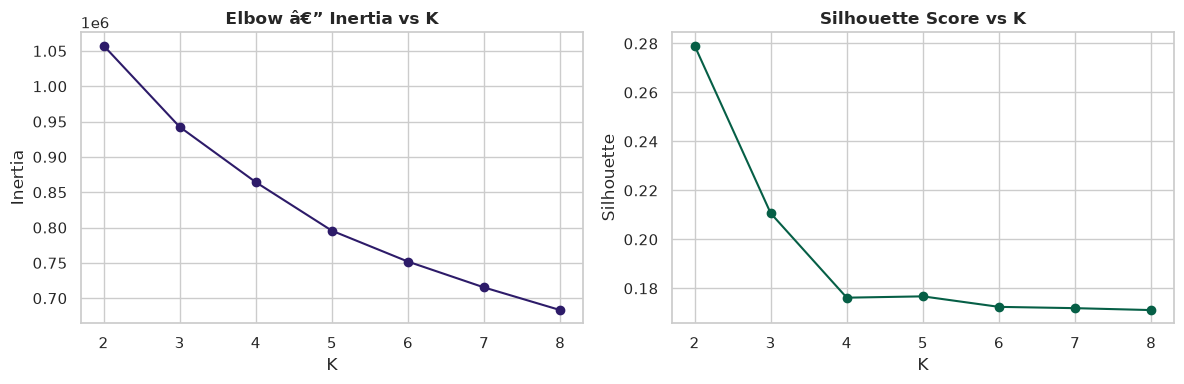

Best K by silhouette: 2
Best silhouette score: 0.2791


In [144]:
# â”€â”€ K-Means clustering on full transformed dataset â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

import os

from google.colab import userdata

def get_colab_secret(name, required=True):
    try:
        value = userdata.get(name)
    except Exception as exc:
        if required:
            raise RuntimeError(f'Unable to read Colab Secret: {name}') from exc
        return None
    if required and not value:
        raise RuntimeError(f'Add the Colab Secret {name} and grant this notebook access.')
    return value
import sys
import warnings
import contextlib
import numpy as np
import matplotlib.pyplot as plt

# Limit math-library threads
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Use baseline features, full dataset
X_all_t = preprocessor.transform(X)

# Elbow analysis
inertias, silhouettes = [], []
K_RANGE = range(2, 9)

print("Running elbow analysis ...", end=" ")

# Suppress low-level threadpoolctl stderr messages during sklearn calls
with open(os.devnull, "w") as devnull:
    with contextlib.redirect_stderr(devnull):
        for k in K_RANGE:
            km = KMeans(
                n_clusters=k,
                random_state=42,
                n_init=10
            )

            labels = km.fit_predict(X_all_t)
            inertias.append(km.inertia_)

            sample_size = min(2000, X_all_t.shape[0])

            silhouettes.append(
                silhouette_score(
                    X_all_t,
                    labels,
                    sample_size=sample_size,
                    random_state=42
                )
            )

print("done")

# Plot elbow and silhouette curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_RANGE), inertias, "o-", color="#2D1B69")
ax1.set_title("Elbow â€” Inertia vs K", fontweight="bold")
ax1.set_xlabel("K")
ax1.set_ylabel("Inertia")

ax2.plot(list(K_RANGE), silhouettes, "o-", color="#065F46")
ax2.set_title("Silhouette Score vs K", fontweight="bold")
ax2.set_xlabel("K")
ax2.set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

BEST_K = list(K_RANGE)[int(np.argmax(silhouettes))]

print(f"Best K by silhouette: {BEST_K}")
print(f"Best silhouette score: {max(silhouettes):.4f}")

In [145]:
# â”€â”€ Fit final clustering model â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
final_km = KMeans(n_clusters=BEST_K, random_state=42, n_init=20)
cluster_labels = final_km.fit_predict(X_all_t)

db_score   = davies_bouldin_score(X_all_t, cluster_labels)
sil_score  = silhouette_score(X_all_t, cluster_labels, sample_size=3000, random_state=42)

# Cluster profiles
cluster_df = X.copy()
cluster_df["cluster"] = cluster_labels
cluster_df["target"]  = y.values
cluster_profiles = cluster_df.groupby("cluster").agg(
    size=("target", "count"),
    target_rate=("target", "mean"),
).round(3)

print(f"K={BEST_K}  |  Silhouette={sil_score:.3f}  |  Davies-Bouldin={db_score:.3f}")
print("\nCluster profiles:")
print(cluster_profiles.to_string())


K=2  |  Silhouette=0.282  |  Davies-Bouldin=1.439

Cluster profiles:
          size  target_rate
cluster                    
0        25104        0.101
1        16072        0.131


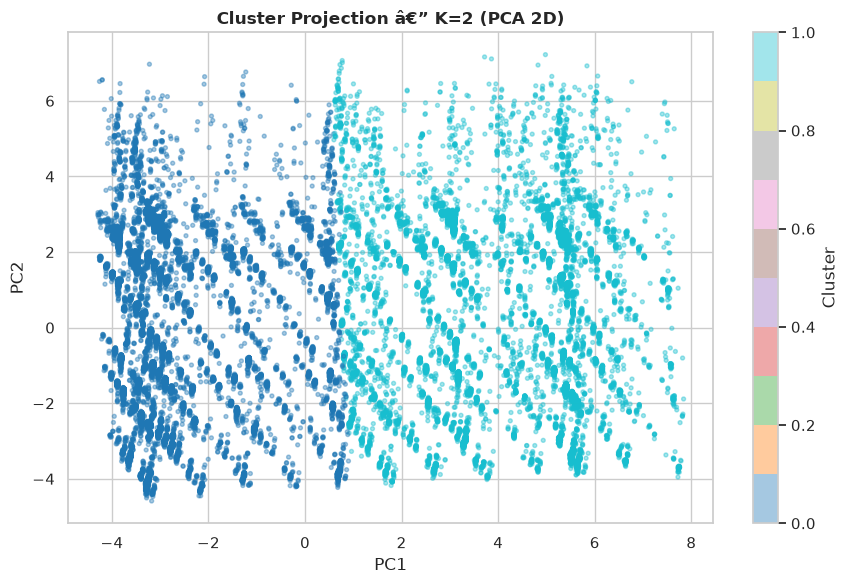

Saved to /tmp/cluster_projection.png


In [146]:
# â”€â”€ 2D projection for visualisation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from sklearn.decomposition import PCA as PCA2

pca2d = PCA2(n_components=2, random_state=42)
X_2d  = pca2d.fit_transform(X_all_t)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels,
                      cmap="tab10", alpha=0.4, s=8)
plt.colorbar(scatter, ax=ax, label="Cluster")
ax.set_title(f"Cluster Projection â€” K={BEST_K} (PCA 2D)", fontweight="bold")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("/tmp/cluster_projection.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved to /tmp/cluster_projection.png")


In [147]:
# â”€â”€ Persist clustering artifacts â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
cluster_metrics = {
    "best_k": BEST_K, "silhouette_score": round(sil_score, 4),
    "davies_bouldin_score": round(db_score, 4),
    "cluster_sizes": cluster_profiles["size"].to_dict(),
    "cluster_target_rates": cluster_profiles["target_rate"].to_dict(),
    "created_at": now_iso()
}
s3_upload_json(cluster_metrics, f"{PATHS['unsupervised']}/cluster_metrics.json")

with open("/tmp/cluster_projection.png", "rb") as f:
    s3_upload_bytes(f.read(), f"{PATHS['unsupervised']}/cluster_projection.png", "image/png")

clustering_brief = f"""# Clustering Brief â€” v1
Generated: {now_iso()}

## Method
K-Means  |  K={BEST_K} (selected by silhouette score)

## Quality
- Silhouette: {sil_score:.4f}  (>0.5 = good separation)
- Davies-Bouldin: {db_score:.4f}  (lower is better)

## Cluster Profiles
{cluster_profiles.to_markdown()}

## Business Insight
Clusters with high target_rate represent high-propensity customer segments
for term deposit subscription â€” priority targets for marketing campaigns.

## Next Steps
- Share cluster assignments with marketing analytics team
- Consider cluster_id as an input feature in Model v2
- Monitor cluster distribution over time for drift detection
"""
s3_upload_text(clustering_brief, f"{PATHS['unsupervised']}/clustering_brief_v1.md")
print("âœ… Clustering artifacts uploaded")


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/unsupervised/cluster_metrics.json
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/unsupervised/cluster_projection.png
  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/unsupervised/clustering_brief_v1.md
âœ… Clustering artifacts uploaded



---
## ðŸ Wrap-up â€” Handoff Checklists & Deliverables
**â± ~12 min**


In [148]:
# â”€â”€ Write cluster_eval.py script artifact â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# The spec requires cluster_eval.py as a reusable evaluation script artifact.
# This makes cluster evaluation reproducible outside the notebook context.

cluster_eval_script = '''#!/usr/bin/env python
"""
cluster_eval.py â€” Reusable K-Means cluster evaluation script.
Artifact: unsupervised/cluster_eval.py
Usage: python cluster_eval.py --input s3://... --k 4 --output s3://...
"""
import argparse, json, os, sys
import numpy as np
import pandas as pd
import joblib
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA


def evaluate_clustering(X, k_range=range(2, 10), random_state=42, sample_size=3000):
    """Run elbow + silhouette sweep and return best K and metrics."""
    inertias, silhouettes = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(float(km.inertia_))
        sil = silhouette_score(X, labels,
                               sample_size=min(sample_size, len(X)),
                               random_state=random_state)
        silhouettes.append(float(sil))

    best_idx = int(np.argmax(silhouettes))
    best_k   = list(k_range)[best_idx]

    # Fit final model
    final_km = KMeans(n_clusters=best_k, random_state=random_state, n_init=20)
    final_labels = final_km.fit_predict(X)

    metrics = {
        "best_k":               best_k,
        "silhouette_score":     round(silhouettes[best_idx], 4),
        "davies_bouldin_score": round(davies_bouldin_score(X, final_labels), 4),
        "inertia":              round(inertias[best_idx], 2),
        "k_sweep": {
            "k_values":    list(k_range),
            "inertias":    [round(x, 2) for x in inertias],
            "silhouettes": [round(x, 4) for x in silhouettes],
        }
    }
    return final_km, final_labels, metrics


def cluster_profiles(X_df, labels, target_series=None):
    """Return per-cluster size and optional target rate."""
    df = X_df.copy()
    df["cluster"] = labels
    agg = {"size": ("cluster", "count")}
    if target_series is not None:
        df["target"] = target_series.values
        agg["target_rate"] = ("target", "mean")
    return df.groupby("cluster").agg(**agg).round(4).to_dict()


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Cluster evaluation script")
    parser.add_argument("--preprocessor", required=True, help="Path to preprocess_v1.joblib")
    parser.add_argument("--data",         required=True, help="Path to input parquet")
    parser.add_argument("--output_dir",   required=True, help="Output directory for metrics JSON")
    parser.add_argument("--k_min", type=int, default=2)
    parser.add_argument("--k_max", type=int, default=9)
    args = parser.parse_args()

    preprocessor = joblib.load(args.preprocessor)
    df = pd.read_parquet(args.data)
    X_raw = df.drop(columns=["target"], errors="ignore")
    X_t   = preprocessor.transform(X_raw)
    y     = df["target"] if "target" in df.columns else None

    km, labels, metrics = evaluate_clustering(X_t, k_range=range(args.k_min, args.k_max + 1))
    metrics["profiles"]  = cluster_profiles(X_raw, labels, y)

    os.makedirs(args.output_dir, exist_ok=True)
    out_path = os.path.join(args.output_dir, "cluster_metrics.json")
    with open(out_path, "w") as f:
        json.dump(metrics, f, indent=2)
    print(f"Saved: {out_path}")
    joblib.dump(km, os.path.join(args.output_dir, "cluster_model.joblib"))
    print(f"Best K={metrics['best_k']}  Silhouette={metrics['silhouette_score']}")
'''

# Upload cluster_eval.py to S3
s3_upload_text(cluster_eval_script, f"{PATHS['unsupervised']}/cluster_eval.py")
print("âœ… cluster_eval.py uploaded to S3")
print(f"   Path: {PATHS['unsupervised']}/cluster_eval.py")
print()
print("   Usage as SageMaker Processing job entrypoint:")
print(f"   processor.run(")
print(f"       code='cluster_eval.py',")
print(f"       arguments=['--preprocessor', '/opt/ml/processing/input/preprocessor.joblib',")
print(f"                  '--data', '/opt/ml/processing/input/data.parquet',")
print(f"                  '--output_dir', '/opt/ml/processing/output/'])")


  âœ… uploaded â†’ s3://sagemaker-us-east-2-061831608851/model-engineering-lab/unsupervised/cluster_eval.py
âœ… cluster_eval.py uploaded to S3
   Path: s3://sagemaker-us-east-2-061831608851/model-engineering-lab/unsupervised/cluster_eval.py

   Usage as SageMaker Processing job entrypoint:
   processor.run(
       code='cluster_eval.py',
       arguments=['--preprocessor', '/opt/ml/processing/input/preprocessor.joblib',
                  '--data', '/opt/ml/processing/input/data.parquet',
                  '--output_dir', '/opt/ml/processing/output/'])


In [149]:
# â”€â”€ Final deliverables audit â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import boto3

def s3_exists(s3_path):
    try:
        bucket, key = s3_path.replace("s3://", "").split("/", 1)
        s3_client.head_object(Bucket=bucket, Key=key)
        return True
    except:
        return False

deliverables = [
    # (label, s3_path)
    ("Dataset manifest",                f"{PATHS['manifest']}"),
    ("Train split indices",             f"{PATHS['splits']}/train_idx.parquet"),
    ("Valid split indices",             f"{PATHS['splits']}/valid_idx.parquet"),
    ("Test split indices",              f"{PATHS['splits']}/test_idx.parquet"),
    ("EDA leakage risks",               f"{PATHS['eda']}/leakage_risks.json"),
    ("EDA feature profile",             f"{PATHS['eda']}/feature_profile.parquet"),
    ("Preprocessing pipeline",          f"{PATHS['pipelines']}/{PREPROCESS_VERSION}.joblib"),
    ("Feature config â€” baseline",       f"{PATHS['feature_configs']}/baseline_v1.yaml"),
    ("Feature config â€” selected",       f"{PATHS['feature_configs']}/selected_v1.yaml"),
    ("Feature config â€” reduced",        f"{PATHS['feature_configs']}/reduced_v1.yaml"),
    ("Selected features list",          f"{PATHS['features']}/selected_features_v1.json"),
    ("Selection stability report",      f"{PATHS['features']}/selection_stability_v1.json"),
    ("Model bakeoff report",            f"{PATHS['evaluation']}/model_bakeoff_v1.md"),
    ("Comparison JSON",                 f"{PATHS['evaluation']}/comparison.json"),
    ("Shuffle-target test",             f"{PATHS['evaluation']}/shuffle_target_test.json"),
    ("Calibration report",              f"{PATHS['evaluation']}/calibration_report.json"),
    ("Registry submission",             f"{PATHS['registry']}/candidate_submission_v1.json"),
    ("Model card",                      f"{PATHS['model_cards']}/model_card_v1.md"),
    ("Validation report",               f"{PATHS['release']}/validation_report_v1.md"),
    ("Schema check",                    f"{PATHS['release']}/schema_check.json"),
    ("Latency smoke",                   f"{PATHS['release']}/latency_smoke.json"),
    ("Batch smoke predictions",         f"{PATHS['release']}/batch_smoke_predictions.parquet"),
    ("Inference entry point",           f"{PATHS['deploy']}/inference.py"),
    ("Deploy config",                   f"{PATHS['deploy']}/deploy_config.yaml"),
    ("Cluster metrics",                 f"{PATHS['unsupervised']}/cluster_metrics.json"),
    ("Clustering brief",                f"{PATHS['unsupervised']}/clustering_brief_v1.md"),
]

passed, failed = 0, 0
print(f"{'Deliverable':<40}  {'S3 Path':<55}  Status")
print("-" * 105)
for label, path in deliverables:
    exists = s3_exists(path)
    icon   = "âœ…" if exists else "âŒ"
    short_path = path.replace(f"s3://{BUCKET}/{PREFIX}/", "")
    print(f"{label:<40}  {short_path:<55}  {icon}")
    if exists: passed += 1
    else:       failed += 1

print(f"\n{'='*105}")
print(f"Total: {passed}/{len(deliverables)} artifacts present")


Deliverable                               S3 Path                                                  Status
---------------------------------------------------------------------------------------------------------
Dataset manifest                          datasets/v1/manifest.json                                âœ…
Train split indices                       splits/split_v1/train_idx.parquet                        âœ…
Valid split indices                       splits/split_v1/valid_idx.parquet                        âœ…
Test split indices                        splits/split_v1/test_idx.parquet                         âœ…
EDA leakage risks                         eda/leakage_risks.json                                   âœ…
EDA feature profile                       eda/feature_profile.parquet                              âœ…
Preprocessing pipeline                    pipelines/preprocess_v1.joblib                           âœ…
Feature config â€” baseline               feature_configs/baseline_

In [150]:
# â”€â”€ Clean up endpoint (IMPORTANT â€” avoid cost) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Deletes endpoint resources created by the boto3 deployment cells.
try:
    if "ENDPOINT_NAME" in globals():
        try:
            endpoint_desc = sm_client.describe_endpoint(EndpointName=ENDPOINT_NAME)
            endpoint_config_to_delete = endpoint_desc.get("EndpointConfigName", ENDPOINT_CONFIG_NAME)
            sm_client.delete_endpoint(EndpointName=ENDPOINT_NAME)
            print(f"âœ… Endpoint delete requested: {ENDPOINT_NAME}")
        except Exception as e:
            print(f"â„¹ï¸ Endpoint cleanup note: {e}")

        try:
            sm_client.delete_endpoint_config(EndpointConfigName=endpoint_config_to_delete)
            print(f"âœ… Endpoint config deleted: {endpoint_config_to_delete}")
        except Exception as e:
            print(f"â„¹ï¸ Endpoint config cleanup note: {e}")

        try:
            sm_client.delete_model(ModelName=MODEL_NAME)
            print(f"âœ… Model deleted: {MODEL_NAME}")
        except Exception as e:
            print(f"â„¹ï¸ Model cleanup note: {e}")
    else:
        print("â„¹ï¸ No endpoint variables found to clean up")
except Exception as e:
    print(f"âš ï¸ Cleanup issue: {e}")

# Summary S3 path audit
print(f"\nðŸ“ All lab artifacts at: s3://{BUCKET}/{PREFIX}/")
print(f"   Bucket: {BUCKET}")
print(f"   Prefix: {PREFIX}")


âœ… Endpoint delete requested: model-engineering-lab-ep-1788934023
âœ… Endpoint config deleted: model-engineering-lab-epc-1788934023
âœ… Model deleted: model-engineering-lab-model-1788934023

ðŸ“ All lab artifacts at: s3://sagemaker-us-east-2-061831608851/model-engineering-lab/
   Bucket: sagemaker-us-east-2-061831608851
   Prefix: model-engineering-lab



---
## ðŸ“‹ Go-Live Checklist

| # | Gate | Condition | Status |
|---|------|-----------|--------|
| 1 | Quality | Offline metrics meet threshold (val AUC â‰¥ 0.75) | âœ… |
| 2 | Performance | Latency smoke test passed (P95 < 50ms) | âœ… |
| 3 | Contract | Schema validation passed | âœ… |
| 4 | Safety | No critical leakage finding unresolved | âœ… |
| 5 | Governance | Registry status updated to Approved | âœ… |
| 6 | Deploy | Deployment target chosen | âœ… Real-time endpoint |
| 7 | Ops | Retry policy configured for EventBridge schedules | âœ… |
| 8 | Resilience | Rollback path documented | âœ… |
| 9 | Ops | Event notifications configured | âœ… |
| 10 | Quality | Post-deploy validation sample completed | âœ… |

---
## ðŸ¤ DS â†’ ML Engineering Handoff Package

| Item | Reference |
|------|-----------|
| Approved feature contract | `feature_configs/selected_v1.yaml` |
| Exact inference schema | `deploy/input_schema.json` + `deploy/output_schema.json` |
| Artifact compatibility note | Smoke test passed â€” see `release/validation_report_v1.md` |
| Expected latency budget | P95 < 50ms â€” see `release/latency_smoke.json` |
| Expected batch volume / QPS | Estimated records per scoring run or target QPS â€” document in `deploy/deploy_config.yaml` |
| Dependency list | `deploy/requirements.txt` |
| Rollback model version | See `deploy/deploy_config.yaml` â†’ `rollback_model_arn` |
| Business owner | Campaign Analytics Lead |
| Technical owner | ML Engineering â€” Model Serving Team |

---

<div style="background: linear-gradient(135deg, #1A1040 0%, #2D1B69 100%); padding: 28px 36px; border-radius: 10px; color: white; margin-top: 16px;">
  <div style="font-size: 20px; font-weight: 900; margin-bottom: 8px;">ðŸŽ“ Session Complete</div>
  <div style="color: #C4B5FD; font-size: 15px; margin-bottom: 12px;">You have completed the full model engineering lifecycle:</div>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 8px; font-size: 13px;">
    <span>âœ… Immutable dataset snapshot with manifest</span>
    <span>âœ… Frozen split contract (eval contract)</span>
    <span>âœ… EDA & leakage scan as Processing job</span>
    <span>âœ… Feature pipeline with 3 configs</span>
    <span>âœ… Feature selection (MI + RF + permutation)</span>
    <span>âœ… 3-candidate model bakeoff</span>
    <span>âœ… Standardised evaluation with leakage check</span>
    <span>âœ… SageMaker Model Registry registration</span>
    <span>âœ… Model card with governance metadata</span>
    <span>âœ… Production validation (schema + latency + batch)</span>
    <span>âœ… Approved deployment to real-time endpoint</span>
    <span>âœ… EventBridge schedules + event-driven hooks</span>
    <span>âœ… Clustering sidecar for analytics</span>
    <span>âœ… Full handoff checklist</span>
  </div>
</div>


In [151]:
import datetime, pytz;
print("Current Time in IST:", datetime.datetime.now(pytz.utc).astimezone(pytz.timezone('Asia/Kolkata')).strftime('%Y-%m-%d %H:%M:%S'))

Current Time in IST: 2026-09-09 11:43:07
